<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 16px; text-align: center; margin-bottom: 20px;">
  <h1 style="color: #e94560; font-size: 2.8em; margin: 0; text-shadow: 2px 2px 4px rgba(0,0,0,0.5);">🧹 Data Cleaning</h1>
</div>

---

## 📚 Table of Contents
1. [Introduction & Golden Rules](#golden-rules)
2. [1. Handling Accuracy Issues](#accuracy)
3. [2. Consistency & Schema Issues](#consistency)
4. [3. Handling Missing Data](#missing)
5. [4. Handling Duplicates](#duplicates)
6. [5. Handling Outliers](#outliers)
7. [6. Time Series – Filling Gaps](#timeseries)
8. [7. Handling Class Imbalance](#imbalance)
9. [8. Building Reusable Pipelines](#pipelines)


## 📦 Setup & Imports

> Run this cell first — all libraries used throughout the notebook are imported here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update(
    {
        'figure.facecolor': 'white',
        'axes.facecolor': '#f8f8f8',
        'axes.edgecolor': '#cccccc',
        'axes.labelcolor': '#222222',
        'xtick.color': '#222222',
        'ytick.color': '#222222',
        'text.color': '#222222',
        'grid.color': '#dddddd',
        'grid.alpha': 0.5,
        'axes.titlecolor': '#111111',
        'figure.titlesize': 14,
    }
)

print("✅ All imports successful!")

✅ All imports successful!


---
<a id="golden-rules"></a>
## 🌟 Introduction: Data Cleaning vs. Transformation

<div style=" border-left: 5px solid #e94560; padding: 20px; border-radius: 8px; margin: 10px 0">

**Data cleaning and transformation** are the systematic set of procedures applied to raw datasets to ensure they are accurate, consistent, and suitable for analysis.

| Stage | Purpose | Examples |
|-------|---------|---------|
| **🧹 Data Cleaning** | Detect & resolve quality issues. Restores data to its *intended correct state*. | Fix wrong values, fill missing data, remove duplicates |
| **⚙️ Data Transformation** | Reshape data for modeling | Normalization, encoding, feature engineering |

</div>



### 🏅 The Golden Rules of Data Cleaning

<div style=" border: 1px solid #e9c46a; border-radius: 10px; padding: 20px">

| # | Rule | Why It Matters |
|---|------|---------------|
| 1️⃣ | **Never overwrite raw data** — always work on a copy | You must be able to re-run from scratch |
| 2️⃣ | **Log every cleaning action** (what, why, how many records) | Reproducibility & audit trail |
| 3️⃣ | **Re-run validation after cleaning** to confirm resolution | Cleaning can introduce new issues |
| 4️⃣ | **Treat cleaning as a pipeline**, not a one-off script | Reusability on new data |

</div>


---
<a id="accuracy"></a>
## 1. 🎯 Handling Data Accuracy Issues

<div style=" border-left:5px solid #e94560; padding:18px; border-radius:8px">

**Definition:** Data does not correctly represent the real-world entity it describes.

Two cleaning strategies:
- <span style="color:#06d6a0">**Rule-based correction**</span> — fix the value when the correct value *can* be inferred
- <span style="color:#e94560">**Record rejection**</span> — quarantine the record when correction would introduce false data

</div>


### 📋 Example Dataset with Accuracy Issues

In [2]:
# Dataset with deliberate accuracy problems
customers_raw = pd.DataFrame(
    {
        'customer_id': [101, 102, 103, 104, 105, 106, 107],
        'name': [
            '  alice smith',
            'BOB JONES',
            'Charlie Brown  ',
            'diana',
            None,
            'EVE MILLER',
            'frank',
        ],
        'age': [25, -30, 150, 40, 35, 28, 200],
        'phone': [
            '(555) 123-4567',
            '555-987-6543',
            '555.246.8101',
            '+1-555-333-4444',
            '5552345678',
            None,
            '555 999 0000',
        ],
        'email': [
            'alice@email.com',
            'bob.email.com',
            'charlie@ok.org',
            'diana@@bad.com',
            'eve@valid.net',
            '',
            'frank@test',
        ],
        'salary': [50000, -5000, 75000, 48000, 90000, 120000, 65000],
    }
)

print("📊 Raw Customer Data (with accuracy problems):")
print(customers_raw.to_string(index=True))
print(f"\nShape: {customers_raw.shape}")

📊 Raw Customer Data (with accuracy problems):
   customer_id             name  age            phone            email  salary
0          101      alice smith   25   (555) 123-4567  alice@email.com   50000
1          102        BOB JONES  -30     555-987-6543    bob.email.com   -5000
2          103  Charlie Brown    150     555.246.8101   charlie@ok.org   75000
3          104            diana   40  +1-555-333-4444   diana@@bad.com   48000
4          105              NaN   35       5552345678    eve@valid.net   90000
5          106       EVE MILLER   28              NaN                   120000
6          107            frank  200     555 999 0000       frank@test   65000

Shape: (7, 6)


### ✅ Strategy 1: Rule-Based Correction

<div style=" border-left:4px solid #06d6a0; padding:16px; border-radius:6px">

Apply domain knowledge as code. If a value violates a rule **but the correct value can be recovered**, fix it programmatically.

**✔️ When to use:**
- The error is *systematic* (e.g., all dates in wrong format)
- The correct value can be derived from other fields
- The violation is minor and a safe default exists

**❌ When NOT to use:**
- The correct value is genuinely unknown
- Making an assumption would introduce **false signal** into your model

</div>


In [3]:
df = customers_raw.copy()  # ✅ Golden Rule #1: work on a copy
# It is a deep copy

# ─────────────────────────────────────────────
# Rule 1: Age must be between 0 and 120
# ─────────────────────────────────────────────
# If age is NEGATIVE → flip sign (common data entry error)
df['age'] = df['age'].apply(lambda x: abs(x) if pd.notna(x) and x < 0 else x)

# If age > 120 → unrecoverable, set to NaN for later imputation
df.loc[df['age'] > 120, 'age'] = None

# NOTE: age becomes float, because NaN is a float value. (float('nan') in Python)
# So when pandas inserts a NaN into an integer column,
# it must convert the entire column to float to accommodate it.
# In pandas 3.0, you can use Int64 (capital I) which is a nullable integer type
# that can hold NaN without converting to float

print("Before:")
print(customers_raw[['customer_id', 'age']].to_string())
print("After age correction:")
print(df[['customer_id', 'age']].to_string())

Before:
   customer_id  age
0          101   25
1          102  -30
2          103  150
3          104   40
4          105   35
5          106   28
6          107  200
After age correction:
   customer_id   age
0          101  25.0
1          102  30.0
2          103   NaN
3          104  40.0
4          105  35.0
5          106  28.0
6          107   NaN


In [4]:
# ─────────────────────────────────────────────
# Rule 2: Standardize phone numbers → digits only
# ─────────────────────────────────────────────
# str.replace with regex=True removes ALL non-digit characters \D
df['phone'] = df['phone'].str.replace(r'\D', '', regex=True)

print("Before:")
print(customers_raw[['customer_id', 'phone']].to_string())
print("\nAfter phone standardization:")
print(df[['customer_id', 'phone']].to_string())

Before:
   customer_id            phone
0          101   (555) 123-4567
1          102     555-987-6543
2          103     555.246.8101
3          104  +1-555-333-4444
4          105       5552345678
5          106              NaN
6          107     555 999 0000

After phone standardization:
   customer_id        phone
0          101   5551234567
1          102   5559876543
2          103   5552468101
3          104  15553334444
4          105   5552345678
5          106          NaN
6          107   5559990000


In [5]:
# ─────────────────────────────────────────────
# Rule 3: Strip whitespace + fix capitalization on names
# ─────────────────────────────────────────────
# str.strip()  → removes leading/trailing spaces
# str.title()  → capitalizes first letter of each word
df['name'] = df['name'].str.strip().str.title()

print("Before:")
print(customers_raw[['customer_id', 'name']].to_string())
print("\nAfter name standardization:")
print(df[['customer_id', 'name']].to_string())

Before:
   customer_id             name
0          101      alice smith
1          102        BOB JONES
2          103  Charlie Brown  
3          104            diana
4          105              NaN
5          106       EVE MILLER
6          107            frank

After name standardization:
   customer_id           name
0          101    Alice Smith
1          102      Bob Jones
2          103  Charlie Brown
3          104          Diana
4          105            NaN
5          106     Eve Miller
6          107          Frank


In [6]:
# ─────────────────────────────────────────────
# Rule 4: Flag invalid emails (do NOT guess the correction)
# ─────────────────────────────────────────────
# Regex pattern: one or more chars, then @, then domain, then .extension
df['email_valid'] = df['email'].str.contains(
    r'^[^@]+@[^@]+\.[^@]+$', regex=True, na=False
)
# na=False ==> means put False if na (important in older pandas versions)


print("\nEmail validation results:")
print(df[['customer_id', 'email', 'email_valid']].to_string())
print(f"\nRecords with invalid email: {(~df['email_valid']).sum()}")


Email validation results:
   customer_id            email  email_valid
0          101  alice@email.com         True
1          102    bob.email.com        False
2          103   charlie@ok.org         True
3          104   diana@@bad.com        False
4          105    eve@valid.net         True
5          106                         False
6          107       frank@test        False

Records with invalid email: 4


### ❌ Strategy 2: Record Rejection (Quarantine)

<div style=" border-left:4px solid #e94560; padding:16px; border-radius:6px">

When a record is so corrupted that **correction would introduce false data**, the safest action is to remove it from the training set.

> ⚠️ **Rejection ≠ Deletion** — Rejected records go to a **quarantine file** for human review, not the trash!

**When to reject:**
- Multiple critical fields are *simultaneously* invalid
- Correct value cannot be inferred from context
- The record would **mislead any model** trained on it

</div>


In [7]:
df2 = customers_raw.copy()

# ─── Define rejection mask (boolean conditions combined with | ) ───────────
reject_mask = (
    (df2['age'] < 0)  # impossible age
    | (df2['age'] > 120)  # impossible age
    | (df2['salary'] < 0)  # impossible salary
    | (~df2['email'].str.contains('@', na=False))  # invalid email
    | (df2['customer_id'].isnull())  # no identifier
)

# ─── Split into clean vs. rejected ────────────────────────────────────────
df_clean = df2[~reject_mask].copy()
df_rejected = df2[reject_mask].copy()


# ─── Add human-readable rejection reason ──────────────────────────────────
def build_reason(row):
    reasons = []
    if pd.notna(row['age']) and (row['age'] < 0 or row['age'] > 120):
        reasons.append('invalid_age')
    if pd.notna(row['salary']) and row['salary'] < 0:
        reasons.append('invalid_salary')
    if '@' not in str(row['email']):
        reasons.append('invalid_email')
    if pd.isna(row['customer_id']):
        reasons.append('missing_id')
    return '; '.join(reasons) if reasons else 'unknown'


# NOTE:
# pd.isna() == pd.isnull()
# pd.notna() == pd.notnull()

df_rejected['rejection_reason'] = df_rejected.apply(build_reason, axis=1)

print(f"✅ Clean records:    {len(df_clean)}")
print(f"🚫 Rejected records: {len(df_rejected)}")
print("\n🚫 Quarantine file preview:")
print(
    df_rejected[
        ['customer_id', 'name', 'age', 'salary', 'email', 'rejection_reason']
    ].to_string()
)

✅ Clean records:    3
🚫 Rejected records: 4

🚫 Quarantine file preview:
   customer_id             name  age  salary           email                            rejection_reason
1          102        BOB JONES  -30   -5000   bob.email.com  invalid_age; invalid_salary; invalid_email
2          103  Charlie Brown    150   75000  charlie@ok.org                                 invalid_age
5          106       EVE MILLER   28  120000                                               invalid_email
6          107            frank  200   65000      frank@test                                 invalid_age


<p style="color: steelblue; font-size: 1.5em;">Side Notes</p>

<p style="color: steelblue; font-size: 1.2em;">Note 1:</p>

<div style="font-size: 1em;">

**The general rule for axis in pandas:**

```python
df.sum(axis=0)  # sum DOWN the rows → one result per column
df.sum(axis=1)  # sum ACROSS columns → one result per row
```

Here axis refers to the **direction of travel** — axis=0 moves down (along rows), axis=1 moves across (along columns).

`.apply()` uses the same logic — axis means direction of travel, not what you receive:
```python
df.apply(func, axis=0)  # func travels DOWN each column
                        # func receives one column at a time (a Series of row values)

df.apply(func, axis=1)  # func travels ACROSS each row
                        # func receives one row at a time (a Series of column values)
```

So `axis=1` means **"move across columns"** — which means you're processing **one row at a time**.
</div>

<p style="color: steelblue; font-size: 1.2em;">Note 2:</p>

<div style="font-size: 1em;">

**DataFrame `.apply()` vs Column `.apply()`**

**DataFrame `.apply()` — what our code uses:**
```python
df_rejected.apply(build_reason, axis=1)
```

- Called on the **whole DataFrame**
- `axis=1` means iterate **row by row**
- Each row is passed as a **Series** to the function, where the index is the column names
- So inside `build_reason`, `row['age']`, `row['salary']` etc. all work
```text
row received by build_reason:
age            25
salary       5000
email     a@b.com
customer_id   101
Name: 0, dtype: object   ← a Series representing one row
```

**Column `.apply()` — called on a single column:**
```python
df['age'].apply(some_function)
```

- Called on **one Series (column)**
- No `axis` parameter needed — it always iterates element by element
- Each individual **value** (not a row) is passed to the function
```python
df['age'].apply(lambda x: x * 2)
# x receives: 25, then 30, then 40 ...  ← a scalar each time
```

</div>

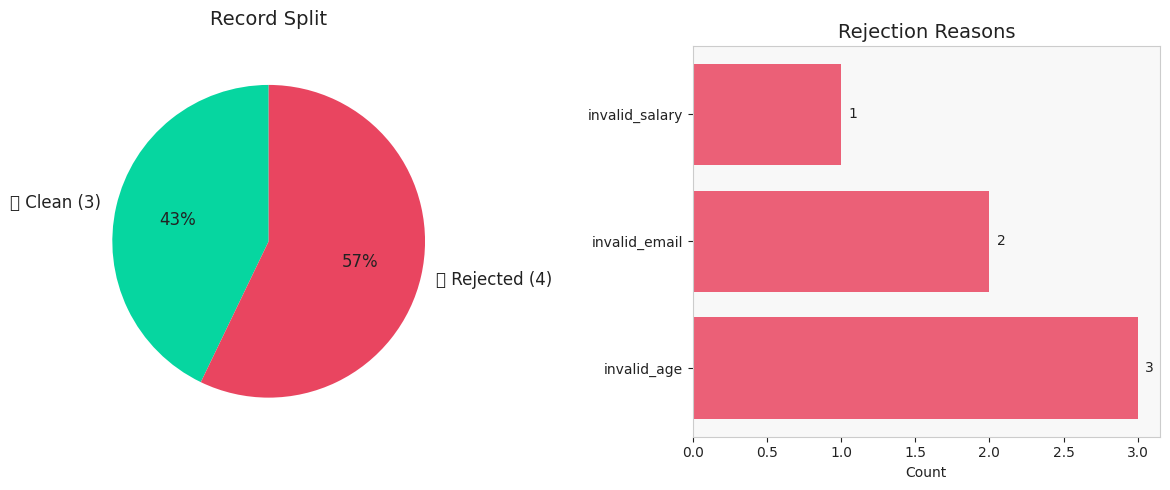

In [8]:
# ─── Visualize the split ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')

# Pie chart
sizes = [len(df_clean), len(df_rejected)]
labels = [f'✅ Clean ({len(df_clean)})', f'🚫 Rejected ({len(df_rejected)})']
colors = ['#06d6a0', '#e94560']
ax1.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.0f%%',
    startangle=90,
    textprops={'color': '#222222', 'fontsize': 12},
)
ax1.set_title('Record Split', color='#222222', fontsize=14, pad=15)
ax1.set_facecolor('#f8f8f8')

# Rejection reasons bar chart
reasons = df_rejected['rejection_reason'].str.split('; ').explode().value_counts()
ax2.barh(reasons.index, reasons.values, color='#e94560', alpha=0.85)
ax2.set_title('Rejection Reasons', color='#222222', fontsize=14)
ax2.set_xlabel('Count', color='#222222')
for i, v in enumerate(reasons.values):
    ax2.text(v + 0.05, i, str(v), color='#222222', va='center')

plt.tight_layout()
plt.show()

---
<a id="consistency"></a>
## 2. 🔄 Handling Consistency & Schema Issues

<div style=" border-left:5px solid #0f9b8e; padding:18px; border-radius:8px">

**Definition:** The same real-world entity is represented in **multiple incompatible ways** across records, systems, or time periods.

Three enforcing strategies:

| Strategy | What it does |
|----------|-------------|
| **Standardization** | Convert all representations to one canonical form |
| **Type Coercion** | Enforce the correct data type per column |
| **Schema Enforcement** | Validate the full structure before analysis |

</div>


### 2.1 📐 Standardization

Convert *all* representations of a value to one canonical form before any analysis.

**Steps:**
1. Audit distinct values (`value_counts()`)
2. Define the target canonical form
3. Write a mapping or transformation function
4. Apply and verify no values were lost


In [9]:
# Dataset with consistency problems
employees_raw = pd.DataFrame(
    {
        'emp_id': [1, 2, 3, 4, 5, 6, 7, 8],
        'hire_date': [
            '2024-01-15',
            '15/02/2024',
            'March 5 2024',
            '2024.04.20',
            'May-10-2024',
            '2024/06/01',
            '07-25-2024',
            '2024-08-30',
        ],
        'gender': ['male', 'Female', 'M', 'f', '1', 'woman', 'Man', 'FEMALE'],
        'country': [
            'USA',
            'United States',
            'US',
            'united states',
            'UAE',
            'United Arab Emirates',
            'uk',
            'United Kingdom',
        ],
        'height': [
            '175cm',
            '5ft 11in',
            '1.8m',
            '168',
            '6ft 0in',
            '1.65m',
            '180cm',
            '5ft 6in',
        ],
        'is_active': ['yes', 'True', '1', 'no', 'false', 'YES', '0', 'NO'],
    }
)

print("📊 Raw Employee Data (with consistency problems):")
print(employees_raw.to_string())

📊 Raw Employee Data (with consistency problems):
   emp_id     hire_date  gender               country    height is_active
0       1    2024-01-15    male                   USA     175cm       yes
1       2    15/02/2024  Female         United States  5ft 11in      True
2       3  March 5 2024       M                    US      1.8m         1
3       4    2024.04.20       f         united states       168        no
4       5   May-10-2024       1                   UAE   6ft 0in     false
5       6    2024/06/01   woman  United Arab Emirates     1.65m       YES
6       7    07-25-2024     Man                    uk     180cm         0
7       8    2024-08-30  FEMALE        United Kingdom   5ft 6in        NO


In [10]:
df_emp = employees_raw.copy()

# ─────────────────────────────────────────────────────────────────────────
# Standardize DATES → ISO 8601 (YYYY-MM-DD)
# pd.to_datetime() auto-detects many formats
# ─────────────────────────────────────────────────────────────────────────
df_emp['hire_date'] = pd.to_datetime(
    df_emp['hire_date'], format='mixed', dayfirst=False
)
df_emp['hire_date'] = df_emp['hire_date'].dt.strftime('%Y-%m-%d')

# In pd.to_datetime():
# converts a string to datetime
# 1- infer_datetime_format:
# was removed in pandas 3.0 — it was deprecated in pandas 2.0 and fully dropped in 3.0.
# Fix — just remove it, pandas 3.0 always infers the format automatically
# 2- format='mixed':
# use it if your data has mixed formats (some rows DD/MM/YYYY, others YYYY-MM-DD etc.)
# 3- dayfirst=False:
# when a date is ambiguous like 01/02/03, treat first number as month not day (US convention). Set True for DD/MM/YYYY data

# .dt is the datetime accessor (like .str for strings).
# .strftime() converts datetime objects back to strings in a format you specify.

print("📅 Dates standardized to ISO 8601:")
print(
    pd.DataFrame({'Before': employees_raw['hire_date'], 'After': df_emp['hire_date']})
)

📅 Dates standardized to ISO 8601:
         Before       After
0    2024-01-15  2024-01-15
1    15/02/2024  2024-02-15
2  March 5 2024  2024-03-05
3    2024.04.20  2024-04-20
4   May-10-2024  2024-05-10
5    2024/06/01  2024-06-01
6    07-25-2024  2024-07-25
7    2024-08-30  2024-08-30


In [11]:
# ─────────────────────────────────────────────────────────────────────────
# Standardize GENDER → canonical labels via mapping dictionary
# ─────────────────────────────────────────────────────────────────────────
# To see the different ways of representation
print(employees_raw['gender'].str.strip().str.lower().unique().tolist())
print()
# Create a mapping dictonary of all the ways
gender_map = {
    'male': 'Male',
    'm': 'Male',
    '1': 'Male',
    'man': 'Male',
    'female': 'Female',
    'f': 'Female',
    '2': 'Female',
    'woman': 'Female',
}
df_emp['gender'] = df_emp['gender'].str.strip().str.lower().map(gender_map)
# .map() takes a dictionary and replaces each value in the Series with its corresponding dictionary value.

print("⚧️ Gender standardized:")
print(pd.DataFrame({'Before': employees_raw['gender'], 'After': df_emp['gender']}))

['male', 'female', 'm', 'f', '1', 'woman', 'man']

⚧️ Gender standardized:
   Before   After
0    male    Male
1  Female  Female
2       M    Male
3       f  Female
4       1    Male
5   woman  Female
6     Man    Male
7  FEMALE  Female


In [12]:
# ─────────────────────────────────────────────────────────────────────────
# Standardize COUNTRY names → canonical labels via mapping dictionary
# ─────────────────────────────────────────────────────────────────────────
# To see the different ways of representation
print(employees_raw['country'].str.strip().str.lower().unique().tolist())
print()
# Create a mapping dictonary of all the ways
country_map = {
    'usa': 'United States',
    'united states': 'United States',
    'us': 'United States',
    'uae': 'United Arab Emirates',
    'united arab emirates': 'United Arab Emirates',
    'uk': 'United Kingdom',
    'united kingdom': 'United Kingdom',
}
df_emp['country'] = df_emp['country'].str.strip().str.lower().map(country_map)

print("🌍 Country standardized:")
print(pd.DataFrame({'Before': employees_raw['country'], 'After': df_emp['country']}))

['usa', 'united states', 'us', 'uae', 'united arab emirates', 'uk', 'united kingdom']

🌍 Country standardized:
                 Before                 After
0                   USA         United States
1         United States         United States
2                    US         United States
3         united states         United States
4                   UAE  United Arab Emirates
5  United Arab Emirates  United Arab Emirates
6                    uk        United Kingdom
7        United Kingdom        United Kingdom


In [13]:
# ─────────────────────────────────────────────────────────────────────────
# Standardize HEIGHT → convert all to centimeters
# ─────────────────────────────────────────────────────────────────────────
def to_cm(value):
    """Convert any height representation to centimeters."""
    v = str(value).strip()
    if 'ft' in v:  # e.g. '5ft 11in' or '6ft 0in'
        parts = v.replace('in', '').split('ft')
        feet = float(parts[0].strip())
        inches = float(parts[1].strip()) if parts[1].strip() else 0
        return round(feet * 30.48 + inches * 2.54, 1)
    elif 'm' in v and 'cm' not in v:  # e.g. '1.8m'
        return round(float(v.replace('m', '')) * 100, 1)
    else:  # e.g. '175cm' or bare number
        return round(float(v.replace('cm', '')), 1)


df_emp['height'] = df_emp['height'].apply(to_cm)
df_emp = df_emp.rename(columns={'height': 'height_cm'})

print("📏 Height converted to cm:")
print(
    pd.DataFrame({'Before': employees_raw['height'], 'After (cm)': df_emp['height_cm']})
)
print()
print(f"employees_raw['height'].dtype = {employees_raw['height'].dtype}")
print(f"df_emp['height_cm'].dtype     = {df_emp['height_cm'].dtype}")

📏 Height converted to cm:
     Before  After (cm)
0     175cm       175.0
1  5ft 11in       180.3
2      1.8m       180.0
3       168       168.0
4   6ft 0in       182.9
5     1.65m       165.0
6     180cm       180.0
7   5ft 6in       167.6

employees_raw['height'].dtype = str
df_emp['height_cm'].dtype     = float64


In [14]:
# ─────────────────────────────────────────────────────────────────────────
# Standardize BOOLEAN fields
# ─────────────────────────────────────────────────────────────────────────
# To see the different ways of representation
print(employees_raw['is_active'].str.strip().str.lower().unique().tolist())
print()
# Create a mapping dictonary of all the ways
bool_map = {
    'yes': True,
    'no': False,
    '1': True,
    '0': False,
    'true': True,
    'false': False,
}
df_emp['is_active'] = df_emp['is_active'].str.strip().str.lower().map(bool_map)

print("✅ Boolean standardized:")
print(
    pd.DataFrame({'Before': employees_raw['is_active'], 'After': df_emp['is_active']})
)

print("\nOriginal non-standardized DataFrame:")
print(employees_raw.to_string())

print("\n✅ Final standardized DataFrame:")
print(df_emp.to_string())

['yes', 'true', '1', 'no', 'false', '0']

✅ Boolean standardized:
  Before  After
0    yes   True
1   True   True
2      1   True
3     no  False
4  false  False
5    YES   True
6      0  False
7     NO  False

Original non-standardized DataFrame:
   emp_id     hire_date  gender               country    height is_active
0       1    2024-01-15    male                   USA     175cm       yes
1       2    15/02/2024  Female         United States  5ft 11in      True
2       3  March 5 2024       M                    US      1.8m         1
3       4    2024.04.20       f         united states       168        no
4       5   May-10-2024       1                   UAE   6ft 0in     false
5       6    2024/06/01   woman  United Arab Emirates     1.65m       YES
6       7    07-25-2024     Man                    uk     180cm         0
7       8    2024-08-30  FEMALE        United Kingdom   5ft 6in        NO

✅ Final standardized DataFrame:
   emp_id   hire_date  gender               country  

### 2.2 🔧 Type Coercion

<div style=" border-left:4px solid #a8dadc; padding:16px; border-radius:6px">

Data loaded from CSV or JSON often has **everything as strings**. Type coercion enforces the correct data type for each column.

**Key pandas parameters:**
- `pd.to_numeric(series, errors='coerce')` — converts strings to numbers; unparseable values become `NaN`
- `pd.to_datetime(series, errors='coerce')` — converts strings to datetime
- `.astype(dtype)` — explicit type casting
- `errors='coerce'` vs `errors='raise'` vs `errors='ignore'`

</div>

| Common Problem | Before | After | Method |
|---|---|---|---|
| Number stored as string | `"42"`, `"N/A"` | `42`, `NaN` | `pd.to_numeric(..., errors='coerce')` |
| Date stored as string | `"2024-01-15"` | `Timestamp('2024-01-15')` | `pd.to_datetime(...)` |
| Float stored as int | `42.0` | `42` | `.astype('Int64')` |
| Bool stored as string | `"True"` | `True` | custom mapping or `.astype(bool)` |


In [15]:
# Dataset demonstrating type coercion issues
orders_raw = pd.DataFrame(
    {
        'order_id': ['001', '002', '003', '004', '005'],
        'age': ['25', '30', 'N/A', '40', 'unknown'],
        'salary': ['50000.0', '75000', 'not_avail', '90000', '65000'],
        'product_id': ['10', '20', None, '40', '50'],
        'created_at': [
            '2024-01-15 09:00',
            '2024-02-20',
            'bad-date',
            '2024-04-30',
            '2024-05-15',
        ],
    }
)

print("📊 Raw types:")
print(orders_raw.dtypes)
print("\nRaw data:")
print(orders_raw)

📊 Raw types:
order_id      str
age           str
salary        str
product_id    str
created_at    str
dtype: object

Raw data:
  order_id      age     salary product_id        created_at
0      001       25    50000.0         10  2024-01-15 09:00
1      002       30      75000         20        2024-02-20
2      003      N/A  not_avail        NaN          bad-date
3      004       40      90000         40        2024-04-30
4      005  unknown      65000         50        2024-05-15


In [16]:
df_orders = orders_raw.copy()

# ── Numeric coercion ─────────────────────────────────────────────────────
# errors='coerce' → turns unparseable values into NaN (safe fallback)
# Int64 (capital I) supports NaN; regular int64 does NOT
# s = pd.array([1, 2, None], dtype='Int64')  # ✅ stays Int64, shows <NA>
# s = pd.array([1, 2, None], dtype='int64')  # ❌ error
df_orders['age'] = pd.to_numeric(df_orders['age'], errors='coerce').astype('Int64')
df_orders['salary'] = pd.to_numeric(df_orders['salary'], errors='coerce').astype(
    'float64'
)

# ── Datetime coercion ────────────────────────────────────────────────────
df_orders['created_at'] = pd.to_datetime(
    df_orders['created_at'], format='mixed', dayfirst=False, errors='coerce'
)

# ── Integer with fallback for NaN ────────────────────────────────────────
# Regular int can't hold NaN, so we fill with sentinel -1 first
df_orders['product_id'] = df_orders['product_id'].fillna(-1).astype(int)

print("Original types:")
print(orders_raw.dtypes)
print("\nOriginal data:")
print(orders_raw)
print()
print("✅ Corrected types:")
print(df_orders.dtypes)
print("\nCleaned data:")
print(df_orders)

# ─── Check how many NaNs were produced by coerce ─────────────────────────
print("\n⚠️  NaN counts created by coercion (large = systematic problem):")
print(df_orders.isna().sum())

Original types:
order_id      str
age           str
salary        str
product_id    str
created_at    str
dtype: object

Original data:
  order_id      age     salary product_id        created_at
0      001       25    50000.0         10  2024-01-15 09:00
1      002       30      75000         20        2024-02-20
2      003      N/A  not_avail        NaN          bad-date
3      004       40      90000         40        2024-04-30
4      005  unknown      65000         50        2024-05-15

✅ Corrected types:
order_id                 str
age                    Int64
salary               float64
product_id             int64
created_at    datetime64[us]
dtype: object

Cleaned data:
  order_id   age   salary  product_id          created_at
0      001    25  50000.0          10 2024-01-15 09:00:00
1      002    30  75000.0          20 2024-02-20 00:00:00
2      003  <NA>      NaN          -1                 NaT
3      004    40  90000.0          40 2024-04-30 00:00:00
4      005  <NA>  65

### 2.3 📋 Schema Enforcement

<div style=" border-left:4px solid #e9c46a; padding:16px; border-radius:6px">

A **schema** defines the expected structure of a dataset: column names, data types, allowed value ranges, and required fields.

Enforcing schema **before any analysis** catches problems at the source.

**Three levels of schema enforcement:**

| Level | Tool | Best For |
|-------|------|---------|
| **Basic** | Python dict + Pandas | Quick validation scripts |
| **Row-level** | Pydantic | API ingestion, rich per-field errors |
| **Production** | Great Expectations | Data pipelines, automated HTML reports |

</div>


#### Level 1: Python Dictionary Schema

In [17]:
# ─── Define schema as a Python dictionary ─────────────────────────────────
SCHEMA = {
    'customer_id': {'dtype': 'int', 'nullable': False},
    'age': {'dtype': 'int', 'nullable': False, 'min': 0, 'max': 120},
    'salary': {'dtype': 'float', 'nullable': True, 'min': 0},
    'email': {'dtype': 'str', 'nullable': False, 'pattern': r'^[^@]+@[^@]+\.[^@]+$'},
    'gender': {
        'dtype': 'str',
        'nullable': True,
        'allowed': ['Male', 'Female', 'Other'],
    },
}

import re


def validate_schema(df, schema):
    """Validate a DataFrame against a schema dictionary.

    Parameters
    ----------
    df     : pd.DataFrame  — the dataset to validate
    schema : dict          — schema definition

    Returns
    -------
    list of violation strings (empty = all good)
    """
    violations = []
    for col, rules in schema.items():
        if col not in df.columns:
            violations.append(f"❌ MISSING COLUMN: {col}")
            continue
        # Null check
        null_count = df[col].isnull().sum()
        if not rules.get('nullable', True) and null_count > 0:
            violations.append(f"❌ {col}: {null_count} nulls in non-nullable column")
        # Min/Max
        if 'min' in rules:
            bad = (df[col].dropna() < rules['min']).sum()
            if bad:
                violations.append(f"❌ {col}: {bad} values below min={rules['min']}")
        if 'max' in rules:
            bad = (df[col].dropna() > rules['max']).sum()
            if bad:
                violations.append(f"❌ {col}: {bad} values above max={rules['max']}")
        # Allowed set
        if 'allowed' in rules:
            bad = (~df[col].dropna().isin(rules['allowed'])).sum()
            if bad:
                violations.append(f"❌ {col}: {bad} values not in {rules['allowed']}")
        # Regex pattern
        if 'pattern' in rules:
            bad = (~df[col].dropna().str.match(rules['pattern'])).sum()
            if bad:
                violations.append(f"❌ {col}: {bad} values fail pattern check")
    return violations


# ─── Test with a dataset that has violations ──────────────────────────────
df_validate = pd.DataFrame(
    {
        'customer_id': [1, 2, None, 4, 5],
        'age': [25, -5, 30, 200, 40],
        'salary': [50000, -1000, 75000, None, 90000],
        'email': ['a@b.com', 'bad-email', 'c@d.org', 'x@@y.net', 'e@f.com'],
        'gender': ['Male', 'Female', 'Alien', 'Male', 'Other'],
    }
)

violations = validate_schema(df_validate, SCHEMA)
if violations:
    print(f"Found {len(violations)} violation(s):\n")
    for v in violations:
        print(" ", v)
else:
    print("✅ No violations found!")

Found 6 violation(s):

  ❌ customer_id: 1 nulls in non-nullable column
  ❌ age: 1 values below min=0
  ❌ age: 1 values above max=120
  ❌ salary: 1 values below min=0
  ❌ email: 2 values fail pattern check
  ❌ gender: 1 values not in ['Male', 'Female', 'Other']


#### Level 2: Pydantic Row-Level Validation

<div style=" border-left:4px solid #a8dadc; padding:12px; border-radius:6px; font-size:0.95em">

**Pydantic** validates data at the *row level* using Python type hints. Ideal when data enters through an API.

- Validators run automatically during model initialization
- Error messages are **precise and per-field**
- `Field(ge=0, le=120)` means `0 ≤ value ≤ 120` (`ge` = greater-than-or-equal, `le` = less-than-or-equal)

</div>


In [ ]:
# pip install pydantic
import pydantic

print(pydantic.__version__)

2.12.5


In [18]:
print(f'Trying to validate this df:')
print(df_validate.to_string())
print()

try:
    from pydantic import BaseModel, Field, field_validator, ValidationError
    from typing import Optional

    class CustomerRecord(BaseModel):
        model_config = {'validate_assignment': True}
        customer_id: int = Field(..., ge=0)
        age: int = Field(..., ge=0, le=120)
        salary: Optional[float] = Field(None, ge=0)
        email: str
        gender: Optional[str] = None

        @field_validator('email')
        @classmethod
        def email_must_be_valid(cls, v):
            if not re.match(r'^[^@]+@[^@]+\.[^@]+$', v):
                raise ValueError(f"Invalid email format: {v}")
            return v.lower()

        @field_validator('gender')
        @classmethod
        def gender_must_be_allowed(cls, v):
            if v is not None and v not in ['Male', 'Female', 'Other']:
                raise ValueError(f"Gender must be Male/Female/Other, got: {v}")
            return v

    # Validate row by row — including rows with NaN customer_id
    clean_rows, rejected_rows = [], []
    for _, row in df_validate.iterrows():  # removed dropna — handle NaN id manually
        try:
            record = CustomerRecord(**row.to_dict())
            clean_rows.append(record.model_dump())
        except ValidationError as e:
            # Uncomment the following line to see the content of e.errors() list of dicts:
            # print(f'e.errors(): \n{e.errors()}\n')

            # include invalid value in each error message
            all_errors = '; '.join(
                [
                    f"{err['loc'][0]}: {err['msg']} (got: {err.get('input', 'N/A')})"
                    for err in e.errors()
                ]
            )
            rejected_rows.append({'row_index': row.name, 'errors': all_errors})

    print(f"✅ Valid rows:   {len(clean_rows)}")
    print(f"❌ Invalid rows: {len(rejected_rows)}")
    print("\nRejected details:")
    for r in rejected_rows:
        print(f"  Row Index {r['row_index']}:")
        for err in r['errors'].split('; '):
            print(f"    • {err}")

except ImportError:
    print("ℹ️  Pydantic not installed.")

Trying to validate this df:
   customer_id  age   salary      email  gender
0          1.0   25  50000.0    a@b.com    Male
1          2.0   -5  -1000.0  bad-email  Female
2          NaN   30  75000.0    c@d.org   Alien
3          4.0  200      NaN   x@@y.net    Male
4          5.0   40  90000.0    e@f.com   Other

✅ Valid rows:   2
❌ Invalid rows: 3

Rejected details:
  Row Index 1:
    • age: Input should be greater than or equal to 0 (got: -5)
    • salary: Input should be greater than or equal to 0 (got: -1000.0)
    • email: Value error, Invalid email format: bad-email (got: bad-email)
  Row Index 2:
    • customer_id: Input should be a finite number (got: nan)
    • gender: Value error, Gender must be Male/Female/Other, got: Alien (got: Alien)
  Row Index 3:
    • age: Input should be less than or equal to 120 (got: 200)
    • salary: Input should be greater than or equal to 0 (got: nan)
    • email: Value error, Invalid email format: x@@y.net (got: x@@y.net)


<p style="color: steelblue; font-size: 1.5em;">Side Notes</p>

<p style="color: steelblue; font-size: 1.2em;">Note 1:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.95em">

`subset` tells `.dropna()` to **only look at specific columns** when deciding which rows to drop, instead of checking all columns.
```python
df_validate.dropna(subset=['customer_id'])
# drop rows where customer_id is NaN
# ignore NaN in all other columns
```

Without `subset`:
```python
df_validate.dropna()
# drops any row that has NaN in ANY column
```

**Visually:**
```text
   customer_id   age   email
0          101    25     NaN   ← kept   (NaN in email, not customer_id)
1          NaN    30   a@b.c   ← dropped (NaN in customer_id)
2          103   NaN     NaN   ← kept   (NaN in age/email, not customer_id)
3          NaN   NaN     NaN   ← dropped (NaN in customer_id)
```

`subset` accepts a list so you can check multiple columns:
```python
df_validate.dropna(subset=['customer_id', 'email'])
# drops rows where customer_id OR email is NaN
```

By default it's **OR** — drops a row if **any** of the subset columns is NaN. You can change this with `how`:
```python
df_validate.dropna(subset=['customer_id', 'email'], how='any')
# drops row if customer_id NaN OR email NaN  ← default

df_validate.dropna(subset=['customer_id', 'email'], how='all')
# drops row only if customer_id NaN AND email NaN
```

</div>

<p style="color: steelblue; font-size: 1.2em;">Note 2:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.95em">


```python
record = CustomerRecord(**row.to_dict())
clean_rows.append(record.model_dump())
```

**Breaking down every piece:**

---

**`row.to_dict()`**

`row` is a pandas Series (one row from `.iterrows()`). `.to_dict()` converts it to a plain Python dictionary where keys are column names and values are the cell values:
```python
row.to_dict()
# {
#   'customer_id': 101,
#   'age': 25,
#   'salary': 5000.0,
#   'email': 'alice@example.com',
#   'gender': 'Female'
# }
```

---

**`**` — dictionary unpacking**

`**` unpacks a dictionary into **keyword arguments**. So:
```python
CustomerRecord(**row.to_dict())
```

is exactly equivalent to:
```python
CustomerRecord(
    customer_id=101,
    age=25,
    salary=5000.0,
    email='alice@example.com',
    gender='Female'
)
```

`**` just saves you from writing each argument manually — it spreads the dictionary keys as argument names and values as argument values.

---

**`CustomerRecord(**row.to_dict())`**

This creates a **Pydantic model instance** from the row data. At this moment Pydantic:
```text
1. receives all field values
2. checks types      → is age an int? is email a str?
3. runs Field rules  → is age between 0 and 120?
4. runs validators   → does email match regex? is gender allowed?
5. if all pass       → creates the object ✅
6. if any fail       → raises ValidationError ❌
```

---

**`record.model_dump()`**

Converts the validated Pydantic model instance back to a plain Python dictionary:
```python
record.model_dump()
# {
#   'customer_id': 101,
#   'age': 25,
#   'salary': 5000.0,
#   'email': 'alice@example.com',  ← normalized to lowercase by validator
#   'gender': 'Female'
# }
```

This is the **clean, validated version** of the row — types are correct, email is normalized, all rules passed.

---

**`clean_rows.append(record.model_dump())`**

Adds the validated dictionary to the `clean_rows` list. At the end, `clean_rows` is a list of dictionaries that can be converted back to a DataFrame:
```python
df_clean = pd.DataFrame(clean_rows)
```

---

**The full flow visually:**
```text
row (Series)
    ↓  .to_dict()
plain dict  {'customer_id': 101, 'age': 25, ...}
    ↓  ** unpacking
CustomerRecord(customer_id=101, age=25, ...)
    ↓  Pydantic validates
    ✅ passes → record object (clean, typed, normalized)
    ❌ fails  → ValidationError → goes to rejected_rows
    ↓  .model_dump()
plain dict  {'customer_id': 101, 'age': 25, ...}
    ↓  .append()
clean_rows list
```

</div>

<p style="color: steelblue; font-size: 1.2em;">Note 3:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.95em">

```python
try:
    record = CustomerRecord(**row.to_dict())
    clean_rows.append(record.model_dump())
except ValidationError as e:
```

`e.errors()` returns a **list of all errors** found in the row — Pydantic validates every field before raising, so all failures are already collected:
```python
e.errors()
# [
#   {'loc': ('age',),   'msg': 'Input should be less than or equal to 120', 'input': 200, ... other items},
#   {'loc': ('email',), 'msg': 'Invalid email format: notanemail', 'input': 'notanemail', ... other items},
# ]
```

Then:
```python
[f"{err['loc'][0]}: {err['msg']} (got: {err.get('input', 'N/A')})" for err in e.errors()]
# ['age: Input should be less than or equal to 120 (got: 200)',
#  'email: Invalid email format: notanemail (got: notanemail)']
```
</div>

---
<a id="missing"></a>
## 3. 🕳️ Handling Data Completeness Issues (Missing Data)

<div style=" border-left:5px solid #e9c46a; padding:18px; border-radius:8px">

Missing data is not just `NaN`! It appears in many disguises.

</div>


### 3.1 Forms of Missing Data

| Form | Examples | How to Detect |
|------|---------|---------------|
| **Explicit** | `NaN`, `None`, `NULL`, `NA` | `df.isnull()` |
| **Implicit placeholders** | `""`, `" "`, `"?"`, `"N/A"`, `"Unknown"`, `"-"` | `str.strip()` + custom check |
| **Sentinel values** | `-999`, `-1`, `9999`, `0` | Domain knowledge |
| **Structural** | Pregnancy data for male patients | Domain knowledge |
| **Temporal** | Future events not yet recorded | Context |


In [19]:
# Dataset demonstrating ALL forms of missing data
df_missing_forms = pd.DataFrame(
    {
        'id': [1, 2, 3, 4, 5, 6, 7, 8],
        'score': [85, None, -999, 92, 0, 78, np.nan, 88],
        'comment': ['Good', '', ' ', '?', 'N/A', 'Excellent', 'Unknown', '-'],
        'income': [50000, 75000, None, 9999, np.nan, 60000, 80000, None],
        'birth_year': [1990, 1985, None, 9999, 1978, None, 1992, 1988],
    }
)

print("📊 All forms of missing data:")
print(df_missing_forms)

# Detect explicit NaN
print("\n1️⃣  Explicit NaN count per column:")
print(df_missing_forms.isnull().sum())

# Detect implicit placeholders in string column
placeholder_values = ['', ' ', '?', 'N/A', 'Unknown', '-', 'null', 'none']
df_missing_forms['comment_placeholder'] = (
    df_missing_forms['comment'].str.strip().isin(placeholder_values)
)
print("\n2️⃣  Implicit placeholder in 'comment':")
print(df_missing_forms[['id', 'comment', 'comment_placeholder']])

# Detect sentinel values
SENTINEL_SCORE = -999
SENTINEL_YEAR = 9999
df_missing_forms['score_sentinel'] = df_missing_forms['score'] == SENTINEL_SCORE
df_missing_forms['year_sentinel'] = df_missing_forms['birth_year'] == SENTINEL_YEAR
print("\n3️⃣  Sentinel values detected:")
print(
    df_missing_forms[['id', 'score', 'score_sentinel', 'birth_year', 'year_sentinel']]
)

📊 All forms of missing data:
   id  score    comment   income  birth_year
0   1   85.0       Good  50000.0      1990.0
1   2    NaN             75000.0      1985.0
2   3 -999.0                 NaN         NaN
3   4   92.0          ?   9999.0      9999.0
4   5    0.0        N/A      NaN      1978.0
5   6   78.0  Excellent  60000.0         NaN
6   7    NaN    Unknown  80000.0      1992.0
7   8   88.0          -      NaN      1988.0

1️⃣  Explicit NaN count per column:
id            0
score         2
comment       0
income        3
birth_year    2
dtype: int64

2️⃣  Implicit placeholder in 'comment':
   id    comment  comment_placeholder
0   1       Good                False
1   2                            True
2   3                            True
3   4          ?                 True
4   5        N/A                 True
5   6  Excellent                False
6   7    Unknown                 True
7   8          -                 True

3️⃣  Sentinel values detected:
   id  score  score_s

### 3.2 Missing Data Patterns

<div style=" border:1px solid #e9c46a; padding:20px; border-radius:10px">

> ⚠️ **Understanding the pattern matters!** The right treatment depends on *why* data is missing.

| Pattern | Full Name | Definition | Example | Danger |
|---------|-----------|------------|---------|--------|
| **MCAR** | Missing Completely At Random | No relationship between missingness and data | Survey response lost due to server crash | Low — safe to delete |
| **MAR** | Missing At Random | Missingness depends on *other observed* variables | Younger people skip income field | Medium — impute carefully |
| **MNAR** | Missing Not At Random | Missingness depends on the *missing value itself* | High earners skip income field | High — no easy fix |

</div>


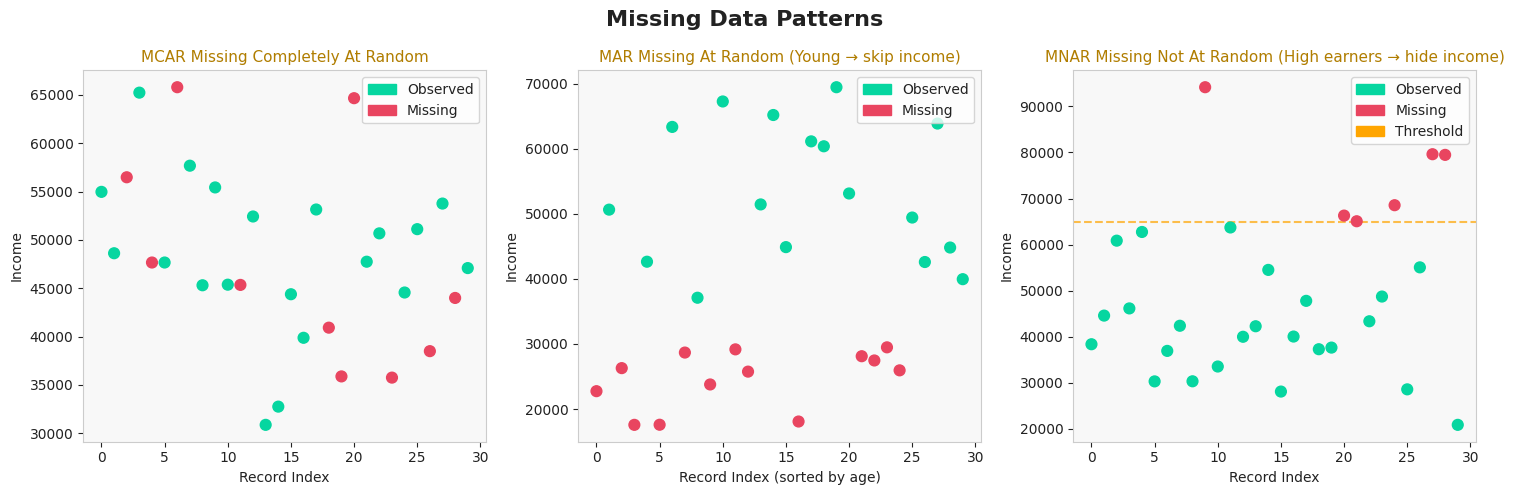

In [20]:
# Visualize missing data patterns conceptually
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('white')
fig.suptitle('Missing Data Patterns', color='#222222', fontsize=16, fontweight='bold')

np.random.seed(42)
n = 30

# ── MCAR ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#f8f8f8')
income_mcar = np.random.normal(50000, 10000, n)
missing_mcar = np.random.choice([True, False], size=n, p=[0.3, 0.7])  # Random
ax.scatter(
    range(n),
    income_mcar,
    c=['#e94560' if m else '#06d6a0' for m in missing_mcar],
    s=60,
    zorder=3,
)
ax.set_title('MCAR Missing Completely At Random', color='#b07d00', fontsize=11)
ax.set_xlabel('Record Index', color='#222222')
ax.set_ylabel('Income', color='#222222')
green = mpatches.Patch(color='#06d6a0', label='Observed')
red = mpatches.Patch(color='#e94560', label='Missing')
ax.legend(handles=[green, red], facecolor='white', labelcolor='#222222')

# ── MAR ───────────────────────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor('#f8f8f8')
age = np.random.randint(18, 70, n)
income_mar = age * 1000 + np.random.normal(0, 5000, n)
# YOUNGER people (age < 35) are more likely to be missing
missing_mar = age < 35
ax.scatter(
    range(n),
    income_mar,
    c=['#e94560' if missing_mar[i] else '#06d6a0' for i in range(n)],
    s=60,
    zorder=3,
)
ax.set_title(
    'MAR Missing At Random (Young → skip income)', color='#b07d00', fontsize=11
)
ax.set_xlabel('Record Index (sorted by age)', color='#222222')
ax.set_ylabel('Income', color='#222222')
ax.legend(handles=[green, red], facecolor='white', labelcolor='#222222')

# ── MNAR ──────────────────────────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor('#f8f8f8')
income_mnar = np.random.normal(50000, 15000, n)
# HIGH earners are more likely to hide income → missingness depends on value
missing_mnar = income_mnar > 65000
ax.scatter(
    range(n),
    income_mnar,
    c=['#e94560' if missing_mnar[i] else '#06d6a0' for i in range(n)],
    s=60,
    zorder=3,
)
ax.axhline(65000, color='orange', linestyle='--', alpha=0.7, label='Threshold (65k)')
ax.set_title(
    'MNAR Missing Not At Random (High earners → hide income)',
    color='#b07d00',
    fontsize=11,
)
ax.set_xlabel('Record Index', color='#222222')
ax.set_ylabel('Income', color='#222222')
ax.legend(
    handles=[green, red, mpatches.Patch(color='orange', label='Threshold')],
    facecolor='white',
    labelcolor='#222222',
)

plt.tight_layout()
plt.show()

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.95em">

These three plots visualize the three types of missing data patterns in statistics.

---

**MCAR — Missing Completely At Random (left plot)**

The red dots (missing values) are scattered randomly with no pattern — they appear at all income levels and all record indices with no logic behind which ones are missing.
```text
Missing because: pure random chance
Example: a survey respondent accidentally skipped a question
Detection: missing values show no relationship to any variable
Impact: least harmful — the observed data is still representative
```

---

**MAR — Missing At Random (middle plot)**

The red dots cluster at the **bottom (low income)** and the x-axis is sorted by age — meaning younger people tend to have lower income AND tend to skip reporting it. The missingness depends on **another observed variable (age)**, not on income itself.
```text
Missing because: depends on another observed column
Example: young people → lower income → more likely to skip reporting income
Detection: missing values correlate with another column (age here)
Impact: manageable — can be handled using the other observed variable
```

---

**MNAR — Missing Not At Random (right plot)**

The red dots cluster **above the orange dashed threshold line** — meaning high earners specifically tend to hide their income. The missingness depends on the **value of the missing column itself**.
```text
Missing because: depends on the hidden value itself
Example: high earners → don't want to report their high income
Detection: very hard — you can't observe what's missing by definition
Impact: most dangerous — creates systematic bias, hardest to fix
```

---

**Summary table:**

| Type | Why missing | Depends on | Difficulty |
|---|---|---|---|
| MCAR | pure chance | nothing | easy |
| MAR | another observed column | age, gender etc. | manageable |
| MNAR | the missing value itself | the hidden income | hard |

</div>

### 3.3 Missing Data Detection

    name   age    email  score  country
0  Alice  25.0  a@b.com     90       US
1    Bob   NaN      N/A     85       UK
2    NaN  30.0  c@d.com   -999       US
3  Diana   NaN              92  Unknown
4    Eve  40.0      NaN     88      NaN

🔍 Missing Data Detection Report

1️⃣  Explicit NaN (df.isnull().sum()):
name       1
age        2
email      1
score      0
country    1


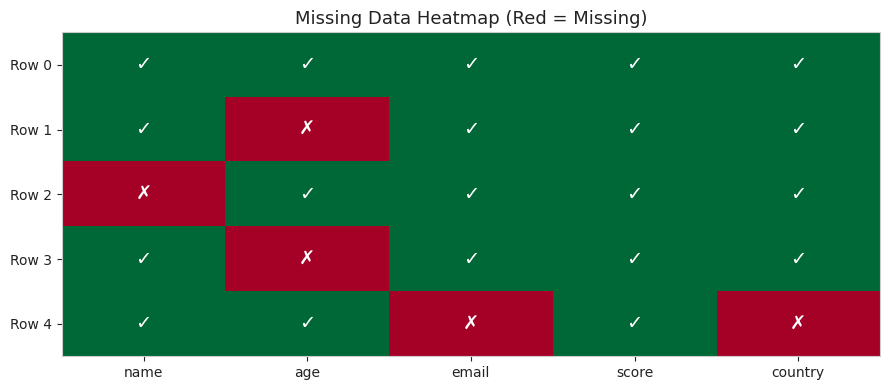

In [21]:
# Dataset for detection demo
df_detect = pd.DataFrame(
    {
        'name': ['Alice', 'Bob', None, 'Diana', 'Eve'],
        'age': [25, np.nan, 30, None, 40],
        'email': ['a@b.com', 'N/A', 'c@d.com', '', None],
        'score': [90, 85, -999, 92, 88],
        'country': ['US', 'UK', 'US', 'Unknown', None],
    }
)

print(df_detect.to_string())

print("\n🔍 Missing Data Detection Report")
print("=" * 45)

# 1. Explicit NaN
print("\n1️⃣  Explicit NaN (df.isnull().sum()):")
print(df_detect.isnull().sum().to_string())

# 2. Heatmap of missing
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f8f8')
miss_matrix = df_detect.isnull().astype(int)
im = ax.imshow(miss_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(df_detect.columns)))
ax.set_xticklabels(df_detect.columns, color='#222222')
ax.set_yticks(range(len(df_detect)))
ax.set_yticklabels([f'Row {i}' for i in range(len(df_detect))], color='#222222')
ax.set_title('Missing Data Heatmap (Red = Missing)', color='#222222', fontsize=13)
for i in range(miss_matrix.shape[0]):
    for j in range(miss_matrix.shape[1]):
        ax.text(
            j,
            i,
            '✗' if miss_matrix.iloc[i, j] else '✓',
            ha='center',
            va='center',
            color='white',
            fontsize=14,
        )
plt.tight_layout()
plt.show()

### 3.4 Handling Missing Data — Deletion

<div style=" border-left:4px solid #e94560; padding:16px; border-radius:6px">

**When to delete:**
- `<5%` missing values (**rule of thumb**)
- Pattern is **MCAR** (safe to drop without bias)

**⚠️ Risk:** May introduce bias if data is NOT MCAR.

</div>


In [22]:
# Dataset for deletion examples
df_del = pd.DataFrame(
    {
        'A': [1, 2, np.nan, 4, 5, np.nan],
        'B': [np.nan, 2, np.nan, 4, np.nan, 6],
        'C': [1, 2, 3, 4, 5, 6],
        'D': [np.nan, np.nan, np.nan, np.nan, np.nan, 6],  # >80% missing
    }
)
print("Original DataFrame:")
print(df_del)
print(f"Shape: {df_del.shape}\n")

# ── dropna() reference ────────────────────────────────────────────────────
# Signature: df.dropna(axis=0, how='any', thresh=None, subset=None)
#
# axis   : 0 = drop rows (default), 1 = drop columns
# how    : 'any' = drop if ANY NaN, 'all' = only drop if ALL NaN
# thresh : keep rows with AT LEAST this many "non"-NaN values
# subset : list of columns to check for NaN (only those matter)

print("1-  dropna()  → remove ALL rows with ANY missing value:")
print(df_del.dropna())
print()

print("2-  dropna(how='all') → remove rows where ALL values are NaN:")
print(df_del.dropna(how='all'))
print()

print("3-  dropna(subset=['A','B']) → remove rows missing in A OR B:")
print(df_del.dropna(subset=['A', 'B']))
print()

print("4-  dropna(subset=['A','B'], how='all') → remove rows missing in A AND B:")
print(df_del.dropna(subset=['A', 'B'], how='all'))
print()

print("5-  dropna(thresh=3) → keep rows with at least 3 non-null values:")
print(df_del.dropna(thresh=3))
print()

print("6-  Drop COLUMNS with >50% missing:")
threshold = 0.5
df_col_drop = df_del.loc[:, df_del.isnull().mean() < threshold]
print(
    f"   Dropped columns: {list(df_del.columns[df_del.isnull().mean() >= threshold])}"
)
print(df_col_drop)

Original DataFrame:
     A    B  C    D
0  1.0  NaN  1  NaN
1  2.0  2.0  2  NaN
2  NaN  NaN  3  NaN
3  4.0  4.0  4  NaN
4  5.0  NaN  5  NaN
5  NaN  6.0  6  6.0
Shape: (6, 4)

1-  dropna()  → remove ALL rows with ANY missing value:
Empty DataFrame
Columns: [A, B, C, D]
Index: []

2-  dropna(how='all') → remove rows where ALL values are NaN:
     A    B  C    D
0  1.0  NaN  1  NaN
1  2.0  2.0  2  NaN
2  NaN  NaN  3  NaN
3  4.0  4.0  4  NaN
4  5.0  NaN  5  NaN
5  NaN  6.0  6  6.0

3-  dropna(subset=['A','B']) → remove rows missing in A OR B:
     A    B  C   D
1  2.0  2.0  2 NaN
3  4.0  4.0  4 NaN

4-  dropna(subset=['A','B'], how='all') → remove rows missing in A AND B:
     A    B  C    D
0  1.0  NaN  1  NaN
1  2.0  2.0  2  NaN
3  4.0  4.0  4  NaN
4  5.0  NaN  5  NaN
5  NaN  6.0  6  6.0

5-  dropna(thresh=3) → keep rows with at least 3 non-null values:
     A    B  C    D
1  2.0  2.0  2  NaN
3  4.0  4.0  4  NaN
5  NaN  6.0  6  6.0

6-  Drop COLUMNS with >50% missing:
   Dropped columns:

<p style="color: steelblue; font-size: 1.2em;">Explanation:</p>


<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.95em">

```python
df_col_drop = df_del.loc[:, df_del.isnull().mean() < threshold]
```

**Step by step on another example:**

---

**`df_del.isnull().mean()`**

`isnull()` returns a boolean DataFrame (True=missing, False=present). 

`.mean()` on a boolean Series treats True=1, False=0 — so it gives the **fraction of missing values per column**:
```text
customer_id    0.00   (0% missing)
age            0.20   (20% missing)
salary         0.60   (60% missing)
email          0.10   (10% missing)
```

---

**`df_del.isnull().mean() < threshold`**

Compares each fraction against `0.5` — returns a boolean Series:
```text
customer_id    True   (0.00 < 0.5)
age            True   (0.20 < 0.5)
salary         False  (0.60 < 0.5) ← will be dropped
email          True   (0.10 < 0.5)
```

---

**`df_del.loc[:, ...]`**

`.loc[rows, columns]` — `:` means keep all rows, and the boolean Series selects only columns where condition is `True`:
```text
keeps:   customer_id, age, email
drops:   salary
```

---

**The dropped columns print:**
```python
df_del.columns[df_del.isnull().mean() >= threshold]
# flipped condition (>=) → shows exactly what was dropped
```


</div>

### 3.5 Simple Imputation

<div style=" border-left:4px solid #06d6a0; padding:16px; border-radius:6px">

**`sklearn.impute.SimpleImputer`**

| Parameter | Values | Effect |
|-----------|--------|--------|
| `strategy` | `'mean'` | Replace with column mean — use for normal distributions |
| `strategy` | `'median'` | Replace with median — robust to outliers |
| `strategy` | `'most_frequent'` | Use mode — best for categorical |
| `strategy` | `'constant'` | Use `fill_value` — when 0 or "Unknown" makes sense |

</div>


In [23]:
from sklearn.impute import SimpleImputer

# Carefully designed data to show effect of mean vs. median
# Notice the outlier (salary=500000) — it will pull the mean far up
df_imp = pd.DataFrame(
    {
        'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Grace'],
        'age': [25, np.nan, 30, np.nan, 35, 40, np.nan],
        'salary': [50000, 55000, np.nan, 60000, 500000, np.nan, 58000],  # has outlier!
        'dept': ['Sales', None, 'Sales', 'HR', None, 'HR', 'HR'],
    }
)

print("Original data:")
print(df_imp)
print(f"\nMean salary (with outlier): ${df_imp['salary'].mean():,.0f}")
print(f"Median salary:              ${df_imp['salary'].median():,.0f}")

print("\n" + "─" * 60)

Original data:
      name   age    salary   dept
0    Alice  25.0   50000.0  Sales
1      Bob   NaN   55000.0    NaN
2  Charlie  30.0       NaN  Sales
3    Diana   NaN   60000.0     HR
4      Eve  35.0  500000.0    NaN
5    Frank  40.0       NaN     HR
6    Grace   NaN   58000.0     HR

Mean salary (with outlier): $144,600
Median salary:              $58,000

────────────────────────────────────────────────────────────


In [24]:
# ── Mean Imputation (sensitive to outliers) ──────────────────────────────
imp_mean = SimpleImputer(strategy='mean')
age_mean = imp_mean.fit_transform(df_imp[['age']])
salary_mean = SimpleImputer(strategy='mean').fit_transform(df_imp[['salary']])

# ── Median Imputation (robust to outliers) ────────────────────────────────
imp_median = SimpleImputer(strategy='median')
age_median = imp_median.fit_transform(df_imp[['age']])
salary_median = SimpleImputer(strategy='median').fit_transform(df_imp[['salary']])

# ── Mode Imputation (for categorical) ─────────────────────────────────────
imp_mode = SimpleImputer(strategy='most_frequent')
dept_mode = imp_mode.fit_transform(df_imp[['dept']])

print("Imputation comparison:")
comparison = pd.DataFrame(
    {
        'name': df_imp['name'],
        'age_original': df_imp['age'],
        'age_mean': age_mean.flatten().round(1),
        'age_median': age_median.flatten().round(1),
        'salary_orig': df_imp['salary'],
        'salary_mean': salary_mean.flatten().round(0),
        'salary_median': salary_median.flatten().round(0),
        'dept_original': df_imp['dept'],
        'dept_mode': dept_mode.flatten(),
    }
)
print(comparison.to_string())

print("\n⚠️  Notice: salary_mean fills missing with $144,500 (pulled by outlier)")
print("    salary_median fills with $57,500 (unaffected by outlier) — much better!")

Imputation comparison:
      name  age_original  age_mean  age_median  salary_orig  salary_mean  salary_median dept_original dept_mode
0    Alice          25.0      25.0        25.0      50000.0      50000.0        50000.0         Sales     Sales
1      Bob           NaN      32.5        32.5      55000.0      55000.0        55000.0           NaN        HR
2  Charlie          30.0      30.0        30.0          NaN     144600.0        58000.0         Sales     Sales
3    Diana           NaN      32.5        32.5      60000.0      60000.0        60000.0            HR        HR
4      Eve          35.0      35.0        35.0     500000.0     500000.0       500000.0           NaN        HR
5    Frank          40.0      40.0        40.0          NaN     144600.0        58000.0            HR        HR
6    Grace           NaN      32.5        32.5      58000.0      58000.0        58000.0            HR        HR

⚠️  Notice: salary_mean fills missing with $144,500 (pulled by outlier)
    sala


<p style="color: steelblue; font-size: 1.2em;">Why .flatten()?</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.95em">

`fit_transform()` returns a **2D numpy array**, even when you give it a single column.

But `pd.DataFrame({...})` expects a **1D array** for each column.

`.flatten()` simply collapses the 2D array into 1D so it fits cleanly as a DataFrame column.

</div>

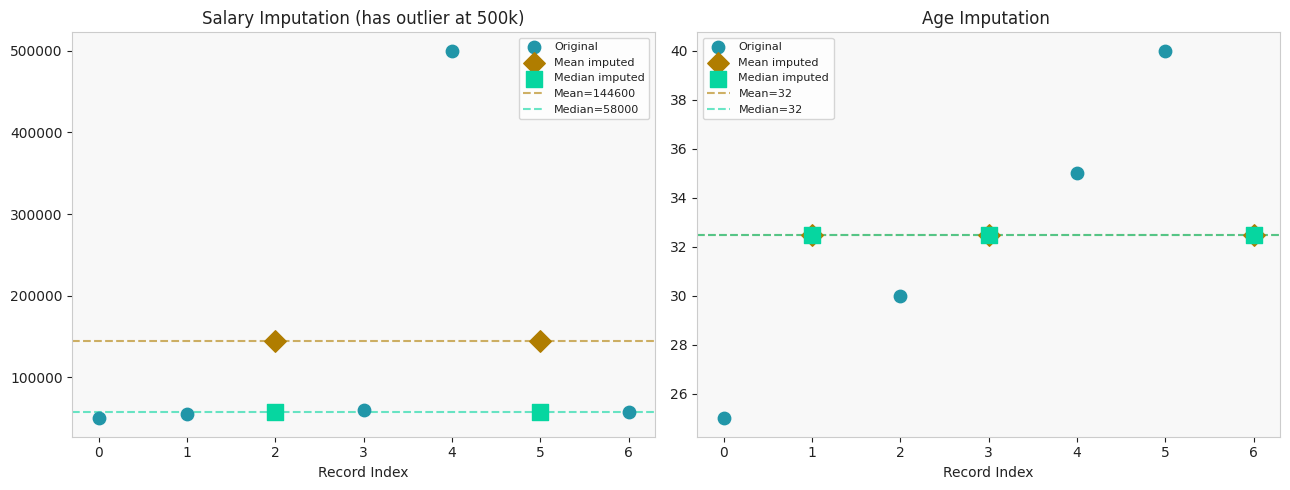

In [25]:
# Visualize mean vs. median imputation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

for ax, col, mean_val, median_val, title_extra in [
    (axes[0], 'salary', salary_mean, salary_median, '(has outlier at 500k)'),
    (axes[1], 'age', age_mean, age_median, ''),
]:
    ax.set_facecolor('#f8f8f8')
    orig = df_imp[col].dropna()
    ax.scatter(
        range(len(df_imp)),
        df_imp[col],
        color='#2196a8',
        s=80,
        label='Original',
        zorder=4,
    )

    missing_mask = df_imp[col].isna()
    ax.scatter(
        np.where(missing_mask)[0],
        mean_val[missing_mask],
        color='#b07d00',
        marker='D',
        s=120,
        label='Mean imputed',
        zorder=5,
    )
    ax.scatter(
        np.where(missing_mask)[0],
        median_val[missing_mask],
        color='#06d6a0',
        marker='s',
        s=120,
        label='Median imputed',
        zorder=5,
    )

    ax.axhline(
        df_imp[col].mean(),
        color='#b07d00',
        linestyle='--',
        alpha=0.6,
        label=f'Mean={df_imp[col].mean():.0f}',
    )
    ax.axhline(
        df_imp[col].median(),
        color='#06d6a0',
        linestyle='--',
        alpha=0.6,
        label=f'Median={df_imp[col].median():.0f}',
    )
    ax.set_title(
        f'{col.title()} Imputation {title_extra}', color='#222222', fontsize=12
    )
    ax.set_xlabel('Record Index', color='#222222')
    ax.legend(facecolor='white', labelcolor='#222222', fontsize=8)

plt.tight_layout()
plt.show()

### 3.6 Advanced Imputation

<div style=" border-left:4px solid #8338ec; padding:16px; border-radius:6px">

**When simple imputation isn't enough**, use these methods:

| Method | How it works | Use when |
|--------|-------------|----------|
| **KNN Imputation** | Fill by averaging *k* nearest rows in feature space | Multiple correlated features |
| **Regression** | Train a model to predict missing values | Clear linear relationship |
| **Iterative (MICE)** | Model each column using all others, cycle repeatedly | Complex, interrelated features |


</div>


In [26]:
from sklearn.impute import KNNImputer, SimpleImputer

# Dataset where features are correlated (height & weight should be)
df_knn = pd.DataFrame(
    {
        'height_cm': [160, 175, np.nan, 180, 155, np.nan, 170, 165],
        'weight_kg': [55, 75, 70, np.nan, 50, 80, np.nan, 60],
        'age': [25, 30, 28, 35, 22, 40, np.nan, 27],
    }
)
print("Original data (height, weight, age are correlated):")
print(df_knn)

# ── KNN Imputation ─────────────────────────────────────────────────────
# n_neighbors: how many neighbors to use for imputation
# weights: 'uniform' (all equal) or 'distance' (closer = more weight)
knn_imputer = KNNImputer(n_neighbors=3, weights='distance')
df_knn_filled = pd.DataFrame(
    knn_imputer.fit_transform(df_knn), columns=df_knn.columns
).round(1)

print("\n✅ After KNN Imputation (n_neighbors=3):")
print(df_knn_filled)

# ── Compare with mean imputation ──────────────────────────────────────────
mean_imputer = SimpleImputer(strategy='mean')
df_mean_filled = pd.DataFrame(
    mean_imputer.fit_transform(df_knn), columns=df_knn.columns
).round(1)

print("\n📊 Comparison — KNN vs. Mean imputation:")
diff = pd.DataFrame(
    {
        'Original': ['160', '175', '❓', '180', '155', '❓', '170', '165'],
        'KNN': df_knn_filled['height_cm'].astype(str),
        'Mean': df_mean_filled['height_cm'].astype(str),
    }
)
print("height_cm:")
print(diff)
print("\n→ KNN uses correlated features (weight, age) to make smarter estimates!")

Original data (height, weight, age are correlated):
   height_cm  weight_kg   age
0      160.0       55.0  25.0
1      175.0       75.0  30.0
2        NaN       70.0  28.0
3      180.0        NaN  35.0
4      155.0       50.0  22.0
5        NaN       80.0  40.0
6      170.0        NaN   NaN
7      165.0       60.0  27.0

✅ After KNN Imputation (n_neighbors=3):
   height_cm  weight_kg   age
0      160.0       55.0  25.0
1      175.0       75.0  30.0
2      173.7       70.0  28.0
3      180.0       75.5  35.0
4      155.0       50.0  22.0
5      176.1       80.0  40.0
6      170.0       65.0  27.8
7      165.0       60.0  27.0

📊 Comparison — KNN vs. Mean imputation:
height_cm:
  Original    KNN   Mean
0      160  160.0  160.0
1      175  175.0  175.0
2        ❓  173.7  167.5
3      180  180.0  180.0
4      155  155.0  155.0
5        ❓  176.1  167.5
6      170  170.0  170.0
7      165  165.0  165.0

→ KNN uses correlated features (weight, age) to make smarter estimates!


### 3.7 Decision Framework

<div style=" border:1px solid #e9c46a; border-radius:10px; padding:20px">

<table style="border-collapse: collapse; width: 100%;">
  <thead>
    <tr style="background-color: #4a90a4; color: white;">
      <th style="padding: 8px; border: 1px solid #ccc;">Scenario</th>
      <th style="padding: 8px; border: 1px solid #ccc;">Recommended Approach</th>
      <th style="padding: 8px; border: 1px solid #ccc;">Reasoning</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #d6eaf8;">
      <td style="padding: 8px; border: 1px solid #ccc;"><b>&lt;5% missing, MCAR</b></td>
      <td style="padding: 8px; border: 1px solid #ccc;">Row Deletion</td>
      <td style="padding: 8px; border: 1px solid #ccc;">Minimal data loss, simple</td>
    </tr>
    <tr style="background-color: #eaf4fb;">
      <td style="padding: 8px; border: 1px solid #ccc;"><b>&gt;20% missing</b></td>
      <td style="padding: 8px; border: 1px solid #ccc;">Column deletion or advanced imputation</td>
      <td style="padding: 8px; border: 1px solid #ccc;">Too much missing data</td>
    </tr>
    <tr style="background-color: #d6eaf8;">
      <td style="padding: 8px; border: 1px solid #ccc;"><b>Numerical, normally distributed</b></td>
      <td style="padding: 8px; border: 1px solid #ccc;">Mean imputation</td>
      <td style="padding: 8px; border: 1px solid #ccc;">Centers distribution</td>
    </tr>
    <tr style="background-color: #eaf4fb;">
      <td style="padding: 8px; border: 1px solid #ccc;"><b>Numerical, skewed</b></td>
      <td style="padding: 8px; border: 1px solid #ccc;">Median imputation</td>
      <td style="padding: 8px; border: 1px solid #ccc;">Robust to outliers</td>
    </tr>
    <tr style="background-color: #d6eaf8;">
      <td style="padding: 8px; border: 1px solid #ccc;"><b>Time series</b></td>
      <td style="padding: 8px; border: 1px solid #ccc;">Forward/backward fill or interpolation</td>
      <td style="padding: 8px; border: 1px solid #ccc;">Preserves temporal patterns</td>
    </tr>
    <tr style="background-color: #eaf4fb;">
      <td style="padding: 8px; border: 1px solid #ccc;"><b>Categorical</b></td>
      <td style="padding: 8px; border: 1px solid #ccc;">Mode or create "Missing" category</td>
      <td style="padding: 8px; border: 1px solid #ccc;">Preserves information</td>
    </tr>
    <tr style="background-color: #d6eaf8;">
      <td style="padding: 8px; border: 1px solid #ccc;"><b>Multiple features correlated</b></td>
      <td style="padding: 8px; border: 1px solid #ccc;">KNN or iterative imputation</td>
      <td style="padding: 8px; border: 1px solid #ccc;">Leverages relationships</td>
    </tr>
    <tr style="background-color: #eaf4fb;">
      <td style="padding: 8px; border: 1px solid #ccc;"><b>Critical feature</b></td>
      <td style="padding: 8px; border: 1px solid #ccc;">Advanced imputation or domain expert</td>
      <td style="padding: 8px; border: 1px solid #ccc;">High stakes decision</td>
    </tr>
  </tbody>
</table>

</div>


---
<a id="duplicates"></a>
## 4. 🔁 Handling Data Uniqueness Issues (Duplicates)

<div style=" border-left:5px solid #a8dadc; padding:18px; border-radius:8px">

**Duplicate records** are rows containing identical or highly similar information.

**Sources:** Multiple data entry, system errors, data merging, user resubmissions.

**Types:**
| Type | Definition | Example |
|------|-----------|---------|
| **Exact duplicates** | All field values identical | Two identical rows |
| **Subset duplicates** | Key fields match, others differ | Same `customer_id`, different timestamps |
| **Fuzzy duplicates** | Tiny variations | `"jon smith"` vs `"john smith"` |

</div>


In [27]:
# Dataset with multiple types of duplicates
df_dupes = pd.DataFrame(
    {
        'customer_id': [1, 2, 2, 3, 4, 4, 4, 5],
        'name': ['Alice', 'Bob', 'Bob', 'Charlie', 'Diana', 'Diana', 'Diana', 'Eve'],
        'email': [
            'a@b.com',
            'b@c.com',
            'b@c.com',
            'c@d.com',
            'd@e.com',
            'd@e.com',
            'd@e.com',
            'e@f.com',
        ],
        'purchase_amount': [100, 250, 250, 300, 50, 75, 120, 400],
        'date': [
            '2024-01-01',
            '2024-01-02',
            '2024-01-02',
            '2024-01-03',
            '2024-01-04',
            '2024-01-05',
            '2024-01-06',
            '2024-01-07',
        ],
    }
)

print("📊 Dataset with duplicates:")
print(df_dupes)
print(f"\nTotal rows:            {len(df_dupes)}")
print(f"Exact duplicate rows:  {df_dupes.duplicated().sum()}")
print(f"Dup by customer_id:    {df_dupes.duplicated(subset=['customer_id']).sum()}")

📊 Dataset with duplicates:
   customer_id     name    email  purchase_amount        date
0            1    Alice  a@b.com              100  2024-01-01
1            2      Bob  b@c.com              250  2024-01-02
2            2      Bob  b@c.com              250  2024-01-02
3            3  Charlie  c@d.com              300  2024-01-03
4            4    Diana  d@e.com               50  2024-01-04
5            4    Diana  d@e.com               75  2024-01-05
6            4    Diana  d@e.com              120  2024-01-06
7            5      Eve  e@f.com              400  2024-01-07

Total rows:            8
Exact duplicate rows:  1
Dup by customer_id:    3


In [28]:
# ── 1. Removing exact duplicates ─────────────────────────────────────────
# drop_duplicates(subset, keep)
# subset : columns to check (None = all columns)
# keep   : 'first', 'last', False (drop ALL occurrences)
print("ORIGINAL:")
print(df_dupes)

print("\n1️⃣  Keep FIRST occurrence of exact duplicates:")
print("df_dupes.drop_duplicates(keep='first')")
print(df_dupes.drop_duplicates(keep='first'))

print("\n2️⃣  Keep LAST occurrence:")
print("df_dupes.drop_duplicates(keep='last')")
print(df_dupes.drop_duplicates(keep='last'))

print("\n3️⃣  Remove based on customer_id — keep first transaction:")
print("df_dupes.drop_duplicates(subset=['customer_id'], keep='first')")
print(df_dupes.drop_duplicates(subset=['customer_id'], keep='first'))

print("\n4️⃣  Remove ALL duplicates (keep=False) — only unique rows survive:")
print("df_dupes.drop_duplicates(keep=False)")
print(df_dupes.drop_duplicates(keep=False))

ORIGINAL:
   customer_id     name    email  purchase_amount        date
0            1    Alice  a@b.com              100  2024-01-01
1            2      Bob  b@c.com              250  2024-01-02
2            2      Bob  b@c.com              250  2024-01-02
3            3  Charlie  c@d.com              300  2024-01-03
4            4    Diana  d@e.com               50  2024-01-04
5            4    Diana  d@e.com               75  2024-01-05
6            4    Diana  d@e.com              120  2024-01-06
7            5      Eve  e@f.com              400  2024-01-07

1️⃣  Keep FIRST occurrence of exact duplicates:
df_dupes.drop_duplicates(keep='first')
   customer_id     name    email  purchase_amount        date
0            1    Alice  a@b.com              100  2024-01-01
1            2      Bob  b@c.com              250  2024-01-02
3            3  Charlie  c@d.com              300  2024-01-03
4            4    Diana  d@e.com               50  2024-01-04
5            4    Diana  d@e.com  

In [29]:
# ── 2. Aggregating duplicates (preserve information) ─────────────────────
# Better when duplicates represent multiple transactions per customer

print("ORIGINAL:")
print(df_dupes)
print()

print("5️⃣  Aggregate duplicates — combine multiple transactions per customer:")
aggregated = (
    df_dupes.groupby(['customer_id', 'name', 'email'])
    .agg(
        total_purchase=('purchase_amount', 'sum'),
        num_transactions=('purchase_amount', 'count'),
        avg_purchase=('purchase_amount', 'mean'),
        first_date=('date', 'min'),
        last_date=('date', 'max'),
    )
    .reset_index()
)

print("\nAggregated (one row per customer with summary stats):")
print(aggregated.to_string())
print("\n→ Diana made 3 transactions: $50, $75, $120 → total $245")

ORIGINAL:
   customer_id     name    email  purchase_amount        date
0            1    Alice  a@b.com              100  2024-01-01
1            2      Bob  b@c.com              250  2024-01-02
2            2      Bob  b@c.com              250  2024-01-02
3            3  Charlie  c@d.com              300  2024-01-03
4            4    Diana  d@e.com               50  2024-01-04
5            4    Diana  d@e.com               75  2024-01-05
6            4    Diana  d@e.com              120  2024-01-06
7            5      Eve  e@f.com              400  2024-01-07

5️⃣  Aggregate duplicates — combine multiple transactions per customer:

Aggregated (one row per customer with summary stats):
   customer_id     name    email  total_purchase  num_transactions  avg_purchase  first_date   last_date
0            1    Alice  a@b.com             100                 1    100.000000  2024-01-01  2024-01-01
1            2      Bob  b@c.com             500                 2    250.000000  2024-01-02  

<p style="color: steelblue; font-size: 1.2em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.95em">

**`.groupby(['customer_id', 'name', 'email'])`**

Groups rows that share the same `customer_id`, `name`, and `email` together — all of Diana's 3 rows become one group, all of Bob's 2 rows become one group, etc.

---

**`.agg(...)`**

Applies aggregation functions to each group. Each argument follows the pattern:
```python
new_column_name = ('existing_column', 'aggregation_function')
```
```python
total_purchase  = ('purchase_amount', 'sum')    # sum all purchases per customer
num_transactions= ('purchase_amount', 'count')  # count number of rows per customer
avg_purchase    = ('purchase_amount', 'mean')   # average purchase per customer
first_date      = ('date', 'min')               # earliest date per customer
last_date       = ('date', 'max')               # latest date per customer
```

---

**`.reset_index()`**

After `groupby + agg`, the group keys (`customer_id`, `name`, `email`) become the index. `.reset_index()` promotes them back to regular columns and resets the index to 0, 1, 2...:

---

**Result:**

Each customer is collapsed into one row with summary statistics — Diana's 3 transactions of $50, $75, $120 become a single row with `total_purchase=245`, `num_transactions=3`, `avg_purchase=81.67`.

</div>

---
<a id="outliers"></a>
## 5. 📈 Handling Data Outlier Issues

<div style=" border-left:5px solid #f4a261; padding:18px; border-radius:8px">

An **outlier** is a data point that differs significantly from other observations.

**Outliers can be:**
- 🐛 **Errors** → data entry mistakes, sensor malfunctions (should be removed/corrected)
- 🌟 **Genuine extreme values** → a billionaire in an income survey (should be kept or capped)

</div>


### 5.1 Detection Methods

#### Method 1: IQR (Interquartile Range)

<div style=" border-left:4px solid #06d6a0; padding:14px; border-radius:6px">

Detects outliers using **quartile spread** — robust to outliers themselves!

- **Q1** = 25th percentile, **Q3** = 75th percentile
- **IQR** = Q3 − Q1
- Outlier if: `value < Q1 − 1.5×IQR` or `value > Q3 + 1.5×IQR`
- Use `3×IQR` for extreme outliers only

</div>


In [30]:
# Dataset designed to clearly show outliers
prices = pd.Series(
    [
        10,
        12,
        11,
        13,
        10,
        14,
        12,
        11,
        13,
        15,
        12,
        200,  # clear outlier
        11,
        13,
        12,
        10,
        14,
        -50,  # negative outlier
        12,
        11,
    ]
)

print(f"Data statistics:")
print(f"  Mean:   {prices.mean():.1f}")
print(f"  Median: {prices.median():.1f}")
print(f"  Std:    {prices.std():.1f}")
print(f"  Min:    {prices.min()}")
print(f"  Max:    {prices.max()}")

# ── IQR Method ─────────────────────────────────────────────────────────
Q1 = prices.quantile(0.25)
Q3 = prices.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\n📐 IQR Method:")
print(f"  Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"  Lower fence (Q1 - 1.5×IQR): {lower_bound}")
print(f"  Upper fence (Q3 + 1.5×IQR): {upper_bound}")

outliers_iqr = prices[(prices < lower_bound) | (prices > upper_bound)]
print(f"\nOutliers detected by IQR: {outliers_iqr.values}")

Data statistics:
  Mean:   18.3
  Median: 12.0
  Std:    45.0
  Min:    -50
  Max:    200

📐 IQR Method:
  Q1=11.0, Q3=13.0, IQR=2.0
  Lower fence (Q1 - 1.5×IQR): 8.0
  Upper fence (Q3 + 1.5×IQR): 16.0

Outliers detected by IQR: [200 -50]


In [ ]:
# ── Z-Score Method ─────────────────────────────────────────────────────
from scipy import stats

z_scores = np.abs(stats.zscore(prices))
threshold = 3  # standard choice: z > 3 is an outlier
print(f'z_scores[z_scores > threshold] = {z_scores[z_scores > threshold]}')
outliers_z = prices[z_scores > threshold]

print(f"📊 Z-Score Method (threshold = {threshold}):")
print(f"  Z-scores: {z_scores.round(2)}")
print(f"  Outliers detected: {outliers_z.values}")

print("\n💡 Z-score = (value - mean) / std")
print(
    f"   Value 200: z = (200 - {prices.mean():.1f}) / {prices.std():.1f} = {(200-prices.mean())/prices.std():.1f}"
)

z_scores[z_scores > threshold]= [4.14508655]
📊 Z-Score Method (threshold = 3):
  Z-scores: [0.19 0.14 0.17 0.12 0.19 0.1  0.14 0.17 0.12 0.08 0.14 4.15 0.17 0.12
 0.14 0.19 0.1  1.56 0.14 0.17]
  Outliers detected: [200]

💡 Z-score = (value - mean) / std
   Value 200: z = (200 - 18.3) / 45.0 = 4.0


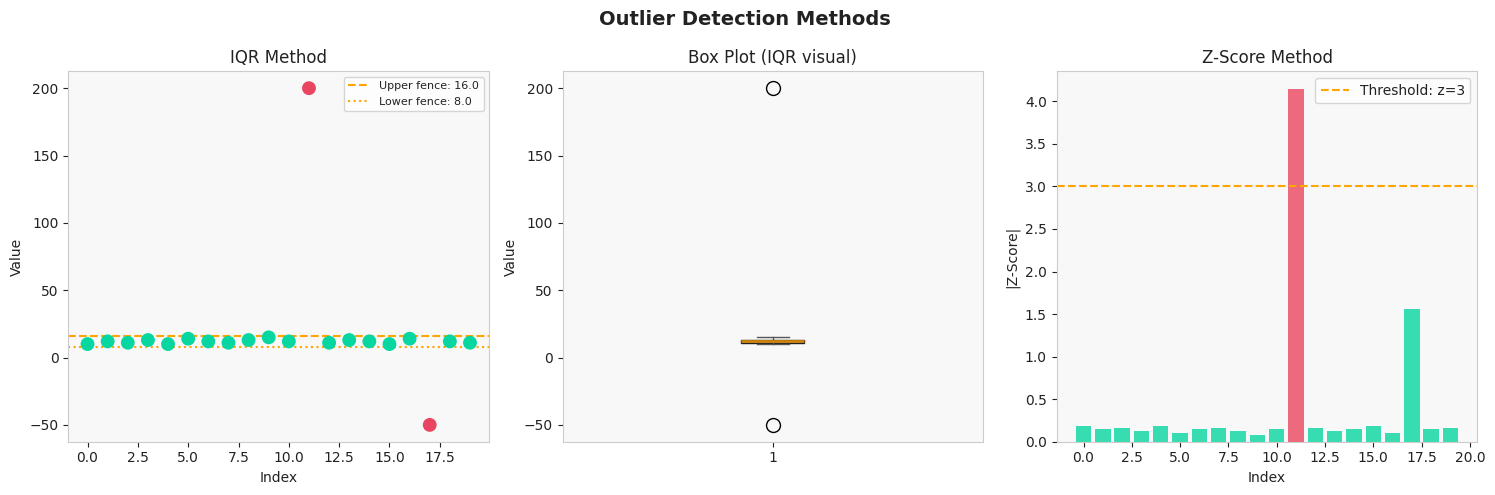

In [36]:
# ── Visualization: Both methods on the same data ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Outlier Detection Methods', color='#222222', fontsize=14, fontweight='bold'
)

colors = [
    '#e94560' if (p < lower_bound or p > upper_bound) else '#06d6a0' for p in prices
]

# Plot 1: Scatter with IQR fences
ax = axes[0]
ax.set_facecolor('#f8f8f8')
ax.scatter(range(len(prices)), prices, c=colors, s=80, zorder=4)
ax.axhline(
    upper_bound, color='orange', linestyle='--', label=f'Upper fence: {upper_bound:.1f}'
)
ax.axhline(
    lower_bound, color='orange', linestyle=':', label=f'Lower fence: {lower_bound:.1f}'
)
ax.set_title('IQR Method', color='#222222')
ax.set_xlabel('Index', color='#222222')
ax.set_ylabel('Value', color='#222222')
ax.legend(facecolor='white', labelcolor='#222222', fontsize=8)

# Plot 2: Boxplot
ax = axes[1]
ax.set_facecolor('#f8f8f8')
bp = ax.boxplot(
    prices,
    patch_artist=True,
    boxprops=dict(facecolor='#0f9b8e', color='#222222'),
    medianprops=dict(color='#d4820a', linewidth=2),
    whiskerprops=dict(color='#555555'),
    capprops=dict(color='#555555'),
    flierprops=dict(marker='o', color='#e94560', markersize=10),
)
ax.set_title('Box Plot (IQR visual)', color='#222222')
ax.set_ylabel('Value', color='#222222')

# Plot 3: Z-score
ax = axes[2]
ax.set_facecolor('#f8f8f8')
z_colors = ['#e94560' if z > threshold else '#06d6a0' for z in z_scores]
ax.bar(range(len(prices)), z_scores, color=z_colors, alpha=0.8)
ax.axhline(threshold, color='orange', linestyle='--', label=f'Threshold: z={threshold}')
ax.set_title('Z-Score Method', color='#222222')
ax.set_xlabel('Index', color='#222222')
ax.set_ylabel('|Z-Score|', color='#222222')
ax.legend(facecolor='white', labelcolor='#222222')

plt.tight_layout()
plt.show()

### 5.2 Outlier Treatment Strategies

<div style=" border-left:4px solid #f4a261; padding:16px; border-radius:6px">

| Strategy | When to Use | Effect |
|----------|-------------|--------|
| **Removal** | Confirmed errors, impossible values | Smaller dataset, no distortion |
| **Capping (Winsorizing)** | Real extremes we want to limit | Preserves sample size |
| **Transformation** | Positive skew, right-tailed distributions | Compresses scale |

</div>


In [39]:
# Extend the dataset to show all three strategies clearly
df_price = pd.DataFrame(
    {
        'product': [
            'A',
            'B',
            'C',
            'D',
            'E',
            'F',
            'G',
            'H',
            'I',
            'J',
            'K',
            'L',
            'M',
            'N',
        ],
        'price': [10, 12, 11, 13, 9, 14, 200, 11, 13, 10, 12, 8, -50, 13],
    }
)

print("Original price data:")
print(df_price)

# ── Strategy 1: Removal ─────────────────────────────────────────────────
print('\n── Strategy 1: Removal ─────────────────────────────────────────────────')
Q1 = df_price['price'].quantile(0.25)
Q3 = df_price['price'].quantile(0.75)
IQR = Q3 - Q1
df_price['is_outlier'] = (df_price['price'] < Q1 - 1.5 * IQR) | (
    df_price['price'] > Q3 + 1.5 * IQR
)
df_removed = df_price[~df_price['is_outlier']].copy()
print(f"\n1️⃣  After REMOVAL: {len(df_price)} → {len(df_removed)} rows")
print(f"   Removed: \n{df_price[df_price['is_outlier']][['product', 'price']]}")

# ── Strategy 2: Capping (Winsorization) ──────────────────────────────────
print('\n── Strategy 2: Capping (Winsorization) ──────────────────────────────────')
# clip(lower, upper) → values below lower become lower; above upper become upper
lower_cap = df_price['price'].quantile(0.05)
upper_cap = df_price['price'].quantile(0.95)
df_price['price_capped'] = df_price['price'].clip(lower=lower_cap, upper=upper_cap)
print(f"\n2️⃣  CAPPING (5th-95th percentile: [{lower_cap:.1f}, {upper_cap:.1f}]):")
print(df_price[['product', 'price', 'price_capped']].to_string())

# ── Strategy 3: Transformation ─────────────────────────────────────────
print('\n── Strategy 3: Transformation ─────────────────────────────────────────')
from scipy.stats import boxcox

# Work with positive values only for transformations
positive_prices = df_price['price'].clip(lower=0.01)  # avoid log(0)
df_price['price_log'] = np.log1p(positive_prices)  # log(1+x) safe for 0
df_price['price_sqrt'] = np.sqrt(positive_prices)
df_price['price_boxcox'], _ = boxcox(positive_prices + 1)

print("\n3️⃣  TRANSFORMATIONS (applied to positive values):")
print(
    df_price[['product', 'price', 'price_log', 'price_sqrt', 'price_boxcox']]
    .round(2)
    .to_string()
)

Original price data:
   product  price
0        A     10
1        B     12
2        C     11
3        D     13
4        E      9
5        F     14
6        G    200
7        H     11
8        I     13
9        J     10
10       K     12
11       L      8
12       M    -50
13       N     13

── Strategy 1: Removal ─────────────────────────────────────────────────

1️⃣  After REMOVAL: 14 → 12 rows
   Removed: 
   product  price
6        G    200
12       M    -50

── Strategy 2: Capping (Winsorization) ──────────────────────────────────

2️⃣  CAPPING (5th-95th percentile: [-12.3, 79.1]):
   product  price  price_capped
0        A     10          10.0
1        B     12          12.0
2        C     11          11.0
3        D     13          13.0
4        E      9           9.0
5        F     14          14.0
6        G    200          79.1
7        H     11          11.0
8        I     13          13.0
9        J     10          10.0
10       K     12          12.0
11       L      8      

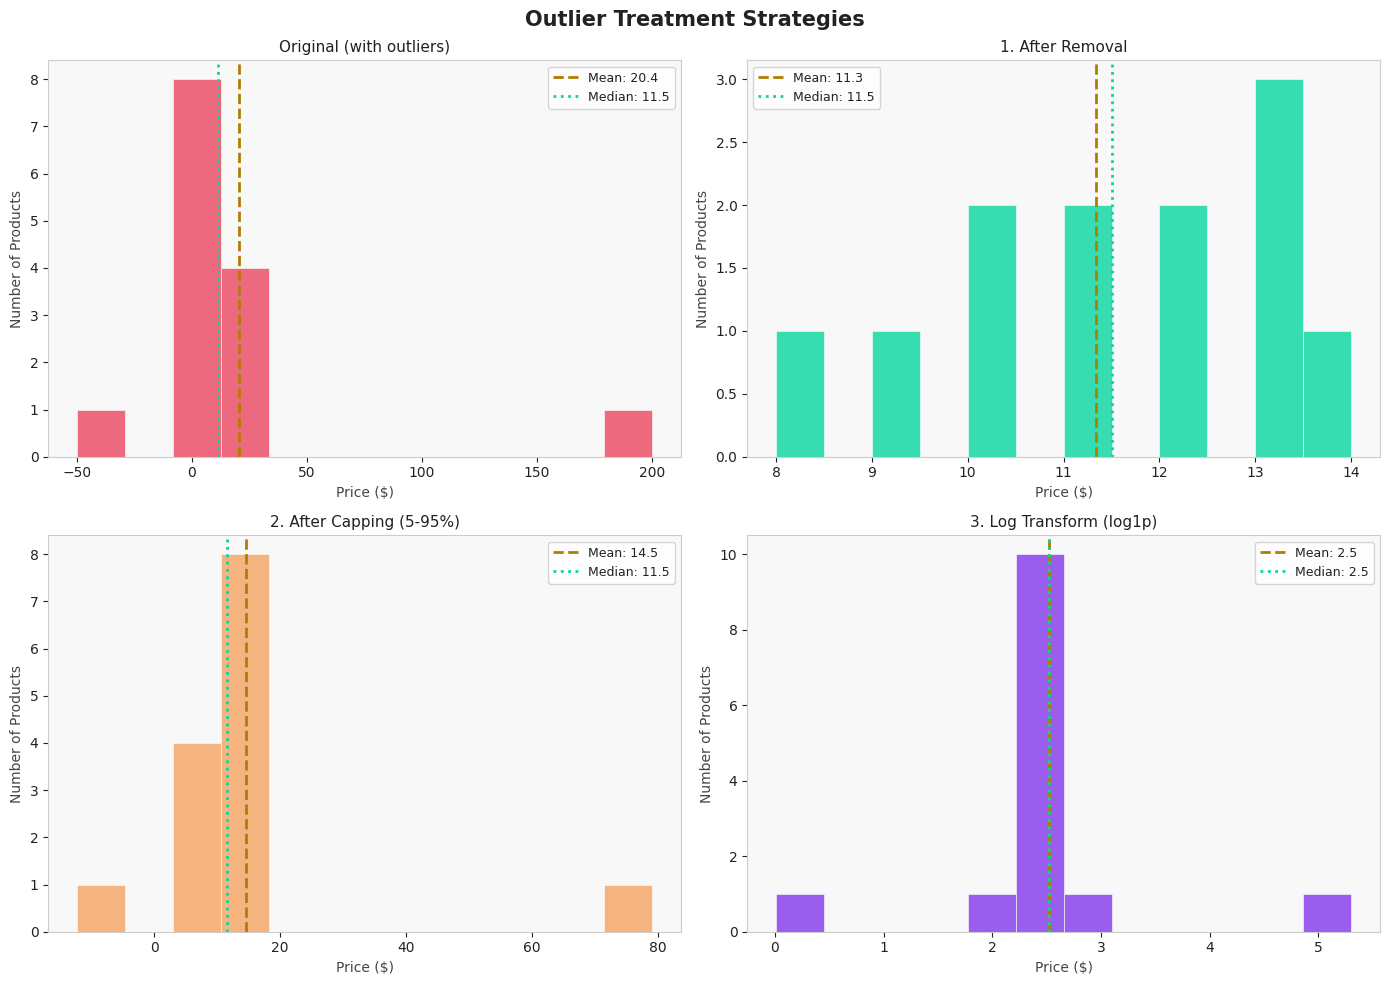

In [41]:
# Visualize all three strategies
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Outlier Treatment Strategies', color='#222222', fontsize=15, fontweight='bold'
)

orig = df_price['price']
axes = axes.flatten()


def plot_dist(ax, data, title, color):
    ax.set_facecolor('#f8f8f8')
    ax.hist(data, bins=12, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(
        data.mean(),
        color='#b07d00',
        linestyle='--',
        linewidth=2,
        label=f'Mean: {data.mean():.1f}',
    )
    ax.axvline(
        data.median(),
        color='#06d6a0',
        linestyle=':',
        linewidth=2,
        label=f'Median: {data.median():.1f}',
    )
    ax.set_title(title, color='#222222', fontsize=11)
    ax.set_xlabel('Price ($)', fontsize=10, color='#444444')  # ← add this
    ax.set_ylabel('Number of Products', fontsize=10, color='#444444')  # ← add this
    ax.legend(facecolor='white', labelcolor='#222222', fontsize=9)


plot_dist(axes[0], orig, 'Original (with outliers)', '#e94560')
plot_dist(axes[1], df_removed['price'], '1. After Removal', '#06d6a0')
plot_dist(axes[2], df_price['price_capped'], '2. After Capping (5-95%)', '#f4a261')
plot_dist(axes[3], df_price['price_log'], '3. Log Transform (log1p)', '#8338ec')

plt.tight_layout()
plt.show()

---
<a id="timeseries"></a>
## 6. ⏱️ Handling Timeliness Issues — Filling Gaps in Time Series

<div style=" border-left:5px solid #8338ec; padding:18px; border-radius:8px">

Time series data often has **gaps** — missing readings at certain timestamps.

Four key filling methods:
| Method | How it works | Best for |
|--------|-------------|---------|
| **ffill** (forward fill) | Copy last known value forward | Sensor readings, prices |
| **bfill** (backward fill) | Copy next known value backward | When future is known |
| **limit** | Restrict consecutive fills | Avoid filling too far |
| **interpolate** | Fit a line between known points | Smooth, continuous data |

</div>


In [ ]:
# Temperature sensor readings with gaps
dates = pd.date_range('2024-01-01', periods=10, freq='D')
temps = pd.Series(
    [20.1, np.nan, np.nan, 23.5, np.nan, 25.0, np.nan, np.nan, np.nan, 22.3],
    index=dates,
    name='temperature',
)

print("🌡️ Raw temperature data (some sensors failed):")
print(temps.to_frame())
# to_frame() converts a Series into a DataFrame
# — essentially wrapping it in a table with a proper column header.

# NOTE: The 'method' parameter was removed from fillna() in newer versions of pandas.
# You now need to use ffill() and bfill() directly instead.

# ── Method 1: Forward Fill ────────────────────────────────────────────────
# fillna(method='ffill') carries last known value forward
# ffill = temps.fillna(method='ffill')  # OLDER PANDAS
ffill = temps.ffill()

# ── Method 2: Backward Fill ───────────────────────────────────────────────
# bfill = temps.fillna(method='bfill')  # OLDER PANDAS
bfill = temps.bfill()

# ── Method 3: Limited Forward Fill ───────────────────────────────────────
# limit=2: fill at most 2 consecutive NaNs (avoids extrapolating too far)
# ffill_limited = temps.fillna(method='ffill', limit=2)  # OLDER PANDAS
ffill_limited = temps.ffill(limit=2)

# ── Method 4: Linear Interpolation ───────────────────────────────────────
# interpolate(method='linear') draws a straight line between known points
interp = temps.interpolate(method='linear')
# interpolate(method='linear') estimates missing values
# by drawing a straight line between the two nearest known values
# and filling in evenly spaced steps.

comparison = pd.DataFrame(
    {
        'Original': temps,
        'ffill': ffill,
        'bfill': bfill,
        'ffill (limit=2)': ffill_limited,
        'interpolated': interp,
    }
)
print("\nComparison of filling methods:")
print(comparison)

🌡️ Raw temperature data (some sensors failed):
            temperature
2024-01-01         20.1
2024-01-02          NaN
2024-01-03          NaN
2024-01-04         23.5
2024-01-05          NaN
2024-01-06         25.0
2024-01-07          NaN
2024-01-08          NaN
2024-01-09          NaN
2024-01-10         22.3

Comparison of filling methods:
            Original  ffill  bfill  ffill (limit=2)  interpolated
2024-01-01      20.1   20.1   20.1             20.1     20.100000
2024-01-02       NaN   20.1   23.5             20.1     21.233333
2024-01-03       NaN   20.1   23.5             20.1     22.366667
2024-01-04      23.5   23.5   23.5             23.5     23.500000
2024-01-05       NaN   23.5   25.0             23.5     24.250000
2024-01-06      25.0   25.0   25.0             25.0     25.000000
2024-01-07       NaN   25.0   22.3             25.0     24.325000
2024-01-08       NaN   25.0   22.3             25.0     23.650000
2024-01-09       NaN   25.0   22.3              NaN     22.9750

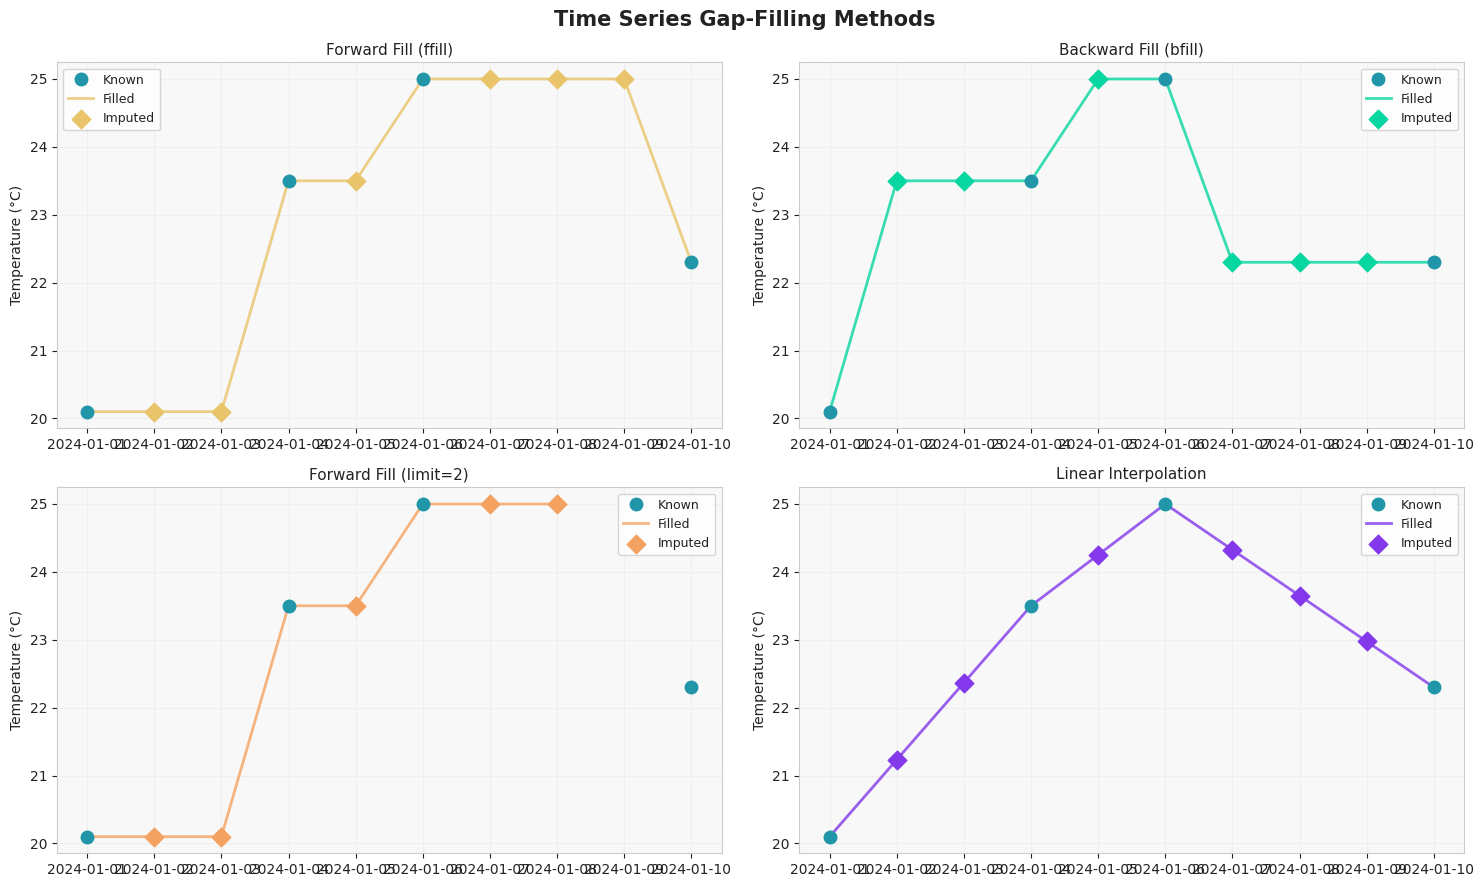

In [44]:
# Visualize all 4 methods
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Time Series Gap-Filling Methods', color='#222222', fontsize=15, fontweight='bold'
)

methods = [
    ('Forward Fill (ffill)', ffill, '#e9c46a'),
    ('Backward Fill (bfill)', bfill, '#06d6a0'),
    ('Forward Fill (limit=2)', ffill_limited, '#f4a261'),
    ('Linear Interpolation', interp, '#8338ec'),
]
for ax, (title, filled, color) in zip(axes.flatten(), methods):
    ax.set_facecolor('#f8f8f8')
    # Original known points
    ax.plot(
        temps.index,
        temps.values,
        'o',
        color='#2196a8',
        markersize=9,
        zorder=5,
        label='Known',
    )
    # Filled values
    ax.plot(
        filled.index,
        filled.values,
        '-',
        color=color,
        alpha=0.8,
        linewidth=2,
        label='Filled',
    )
    # Mark where NaN was
    nan_mask = temps.isna()
    ax.scatter(
        temps.index[nan_mask],
        filled[nan_mask],
        color=color,
        marker='D',
        s=90,
        zorder=6,
        label='Imputed',
    )
    ax.set_title(title, color='#222222', fontsize=11)
    ax.set_ylabel('Temperature (°C)', color='#222222')
    ax.legend(facecolor='white', labelcolor='#222222', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
<a id="imbalance"></a>
## 7. ⚖️ Handling Data Imbalance Issues

<div style=" border-left:5px solid #06d6a0; padding:18px; border-radius:8px">

**Class imbalance** occurs when classes have very different frequencies.

**Example:** Fraud detection — 0.1% fraud, 99.9% legitimate transactions.

**Why it matters:**
- 🎯 **Model bias**: Classifiers favor the majority class
- 📉 **Poor minority recall**: Few examples to learn from
- 🚨 **Misleading accuracy**: 99.9% accuracy by predicting "not fraud" every time!

</div>

### Imbalance Ratio (IR)

<div style=" border-left:4px solid #e9c46a; padding:14px; border-radius:6px">

**IR = (Majority class count) / (Minority class count)**

| IR | Level | Action |
|----|-------|--------|
| ≤ 3:1 | Mild | Often OK with standard methods |
| 3:1 – 9:1 | Moderate | Needs attention |
| ≥ 9:1 | Severe | Requires specialized techniques |
| > 100:1 | Extreme | Treat as anomaly detection |

</div>


In [ ]:
# Create an imbalanced dataset (churn prediction scenario)
np.random.seed(42)
n_total = 1000
n_churn = 50  # 5% churn rate → IR = 950/50 = 19:1

churn_customers = pd.DataFrame(
    {
        'customer_id': range(1, n_churn + 1),
        'monthly_spend': np.random.normal(30, 10, n_churn),
        # np.random.normal(loc, scale, size): loc -> mean, scale -> std, size -> num elements
        'tenure_months': np.random.randint(1, 12, n_churn),  # 1-11
        # Tenure = how long a customer has been with the company, usually measured in months or years.
        'support_calls': np.random.randint(5, 15, n_churn),  # 5-14
        'label': 1,  # churned
    }
)
loyal_customers = pd.DataFrame(
    {
        'customer_id': range(n_churn + 1, n_total + 1),
        'monthly_spend': np.random.normal(75, 20, n_total - n_churn),
        'tenure_months': np.random.randint(6, 60, n_total - n_churn),
        'support_calls': np.random.randint(0, 5, n_total - n_churn),
        'label': 0,  # loyal
    }
)
df_churn = (
    pd.concat([churn_customers, loyal_customers])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
# - pd.concat([churn_customers, loyal_customers]): Stacks the two DataFrames vertically into one
# - .sample(frac=1, random_state=42): Shuffles the rows randomly
#   - frac=1  →  sample 100% of rows = shuffle everything
# - .reset_index(drop=True): Resets row numbers after shuffling
#   Before reset:   index = [847, 3, 521, 12, ...]  # messy after shuffle
#   After reset:    index = [0, 1, 2, 3, ...]        # clean 0-based index
#   - drop=True  →  discards the old index instead of adding it as a column

print("📊 Churn Dataset Overview:")
print(df_churn['label'].value_counts())
print()
print(df_churn['label'].value_counts().rename({0: 'Loyal (0)', 1: 'Churned (1)'}))
# - .rename({0: 'Loyal (0)', 1: 'Churned (1)'}): Replaces index labels with readable names
IR = len(df_churn[df_churn.label == 0]) / len(df_churn[df_churn.label == 1])
print(f"\nImbalance Ratio (IR) = {IR:.1f}:1  → {'Severe ⚠️' if IR >= 9 else 'Moderate'}")

📊 Churn Dataset Overview:
label
0    950
1     50
Name: count, dtype: int64

label
Loyal (0)      950
Churned (1)     50
Name: count, dtype: int64

Imbalance Ratio (IR) = 19.0:1  → Severe ⚠️


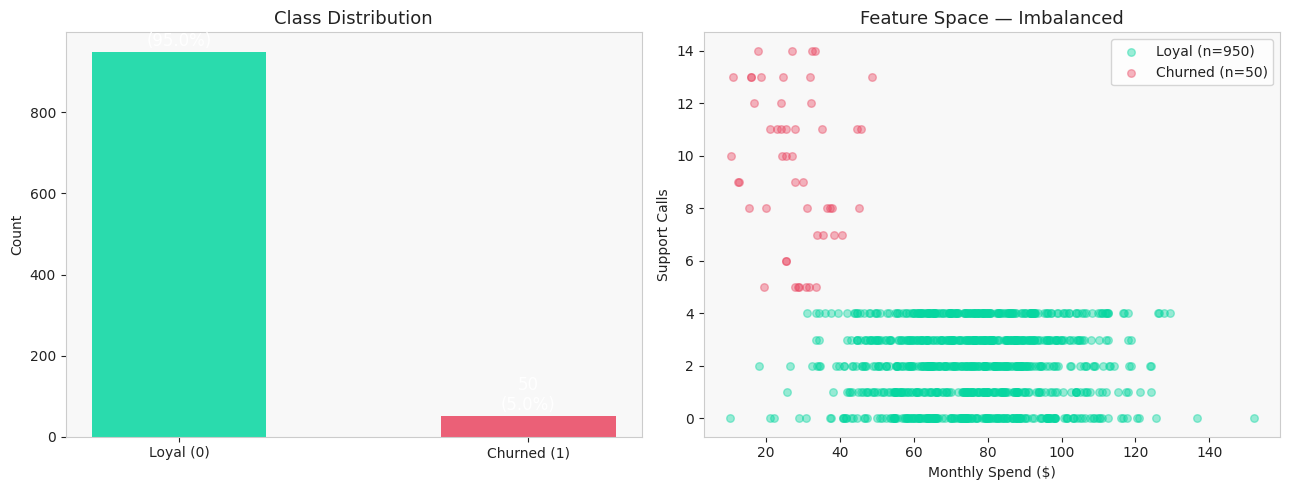

In [52]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

# Bar chart
ax = axes[0]
ax.set_facecolor('#f8f8f8')
counts = df_churn['label'].value_counts()
bars = ax.bar(
    ['Loyal (0)', 'Churned (1)'],
    counts.values,
    color=['#06d6a0', '#e94560'],
    alpha=0.85,
    width=0.5,
)
for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'{count}\n({count/n_total*100:.1f}%)',
        ha='center',
        color='white',
        fontsize=12,
    )
ax.set_title('Class Distribution', color='#222222', fontsize=13)
ax.set_ylabel('Count', color='#222222')

# Feature scatter
ax = axes[1]
ax.set_facecolor('#f8f8f8')
for label, color, name in [(0, '#06d6a0', 'Loyal'), (1, '#e94560', 'Churned')]:
    subset = df_churn[df_churn.label == label]
    ax.scatter(
        subset['monthly_spend'],
        subset['support_calls'],
        c=color,
        alpha=0.4,
        s=30,
        label=f'{name} (n={len(subset)})',
    )
ax.set_xlabel('Monthly Spend ($)', color='#222222')
ax.set_ylabel('Support Calls', color='#222222')
ax.set_title('Feature Space — Imbalanced', color='#222222', fontsize=13)
ax.legend(facecolor='white', labelcolor='#222222')

plt.tight_layout()
plt.show()

### 7.1 Resampling Techniques

<div style=" border:1px solid #06d6a0; border-radius:8px; padding:16px">

> ⚠️ **Critical Rule:** Apply resampling to **TRAINING data only!** Never to test data.

**Techniques:**
1. **Random Oversampling** — duplicate minority samples (fast, risk of overfitting)
2. **SMOTE** — create *synthetic* minority samples (best practice)
3. **Random Undersampling** — remove majority samples (loses information)
4. **Tomek Links** — remove majority samples near boundary (cleanup step)

</div>


In [ ]:
# Uncomment if not installed:
# pip install imblearn

In [ ]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

# Prepare features and labels
X = df_churn[['monthly_spend', 'tenure_months', 'support_calls']].values
y = df_churn['label'].values
# - .values returns the raw numpy array underneath a DataFrame or Series,
#   stripping away all pandas labels (index, column names)

print(f"Before resampling: {dict(zip(*np.unique(y, return_counts=True)))}")
# Output: {np.int64(0): np.int64(950), np.int64(1): np.int64(50)}
# which is {0: 950, 1: 50} --> {y label: count}
# OR more clearly
unique, counts = np.unique(y, return_counts=True)
print(f"Before resampling: {dict(zip(unique.tolist(), counts.tolist()))}")

# ── 1. Random Oversampling ─────────────────────────────────────────────
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)
print(f"\n1️⃣  Random Oversampling: {dict(zip(*np.unique(y_ros, return_counts=True)))}")

# ── 2. SMOTE ──────────────────────────────────────────────────────────
smote = SMOTE(k_neighbors=5, random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)
print(f"2️⃣  SMOTE:              {dict(zip(*np.unique(y_smote, return_counts=True)))}")

# ── 3. Random Undersampling ───────────────────────────────────────────
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)
print(f"3️⃣  Random Undersampling: {dict(zip(*np.unique(y_rus, return_counts=True)))}")

# Manual demonstration of the concept
print("\n📚 SMOTE concept (manual illustration):")
# The first six rows of churn with the two columns
minority = df_churn[df_churn.label == 1][['monthly_spend', 'support_calls']].values[:6]
print("Minority samples:")
for i, s in enumerate(minority):
    print(f"  Sample {i}: spend={s[0]:.1f}, calls={s[1]:.0f}")

# Simulate creating one synthetic point
p1, p2 = minority[0], minority[1]
alpha = np.random.uniform(0, 1)
synthetic = p1 + alpha * (p2 - p1)
print(f"\nSynthetic sample (interpolation between Sample 0 and 1, α={alpha:.2f}):")
print(f"  Synthetic: spend={synthetic[0]:.1f}, calls={synthetic[1]:.1f}")
print("\n→ SMOTE creates many such synthetic points to balance the dataset!")

Before resampling: {np.int64(0): np.int64(950), np.int64(1): np.int64(50)}
Before resampling: {0: 950, 1: 50}

1️⃣  Random Oversampling: {np.int64(0): np.int64(950), np.int64(1): np.int64(950)}
2️⃣  SMOTE:              {np.int64(0): np.int64(950), np.int64(1): np.int64(950)}
3️⃣  Random Undersampling: {np.int64(0): np.int64(50), np.int64(1): np.int64(50)}

📚 SMOTE concept (manual illustration):
Minority samples:
  Sample 0: spend=15.8, calls=13
  Sample 1: spend=24.0, calls=12
  Sample 2: spend=25.4, calls=10
  Sample 3: spend=32.0, calls=13
  Sample 4: spend=31.1, calls=8
  Sample 5: spend=15.2, calls=8

Synthetic sample (interpolation between Sample 0 and 1, α=0.82):
  Synthetic: spend=22.5, calls=12.2

→ SMOTE creates many such synthetic points to balance the dataset!


<p style="color: steelblue; font-size: 1.5em;">Side Notes</p>

<p style="color: steelblue; font-size: 1.2em;">Note 1:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.8em">

**`print(f"Before resampling: {dict(zip(*np.unique(y, return_counts=True)))}")`**

Breaking down the complex inner part:

---

**`np.unique(y, return_counts=True)`**
Returns two arrays — unique values and their counts:
```python
np.unique([0,0,0,1,1], return_counts=True)
# (array([0, 1]),       ← unique values
#  array([3, 2]))       ← their counts
```

---

**`*` (unpacking)**
The `*` splits that tuple into two separate arrays so `zip` can receive them:
```python
# Without *
zip( (array([0,1]), array([700,300])) )  # ❌ zip gets 1 argument (a tuple)

# With *
zip( array([0,1]), array([700,300]) )    # ✅ zip gets 2 separate arrays
```

---

**`zip(...)`**
Pairs up values with their counts:
```python
zip([0, 1], [700, 300])
# → (0, 700), (1, 300)
```

---

**`dict(...)`**
Converts those pairs into a dictionary:
```python
dict([(0, 700), (1, 300)])
# → {0: 700, 1: 300}
```

---

**Final output:**
```
Before resampling: {0: 700, 1: 300}
```


</div>

<p style="color: steelblue; font-size: 1.2em;">Note 2:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.8em">

**SMOTE — Synthetic Minority Oversampling Technique**

A way to fix **class imbalance** by **creating synthetic new samples** of the minority class, rather than just duplicating existing ones.

---

**The problem it solves:**
```python
Before SMOTE:   {0: 950, 1: 50}   → 95% loyal, 5% churned
                                     model just predicts 0 every time = 95% accuracy
                                     but useless — never catches churners
```

---

**How it works:**
Instead of copying existing minority rows, SMOTE **interpolates between them**:
```
Existing churner A:  [spend=20, tenure=5,  calls=8]
Existing churner B:  [spend=30, tenure=9,  calls=6]

Synthetic sample:    [spend=25, tenure=7,  calls=7]  ← point between A and B
```

It picks a real minority sample, finds its nearest neighbours, then creates a new point **somewhere along the line between them**.

---

**Usage:**
```python
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

# Before: {0: 950, 1: 50}
# After:  {0: 950, 1: 950}  ← minority class boosted to match majority
```

---

**SMOTE vs other approaches:**

| Approach | What it does | Downside |
|----------|-------------|----------|
| Do nothing | Model ignores minority | Misses churners |
| Duplicate rows | Copies existing samples | Model memorizes, overfits |
| **SMOTE** | Creates new synthetic samples | More generalizable |
| Undersample majority | Deletes majority rows | Loses real data |

---

SMOTE only applies to **training data** — never apply it before the train/test split, otherwise synthetic samples leak into your test set and inflate your metrics.

</div>

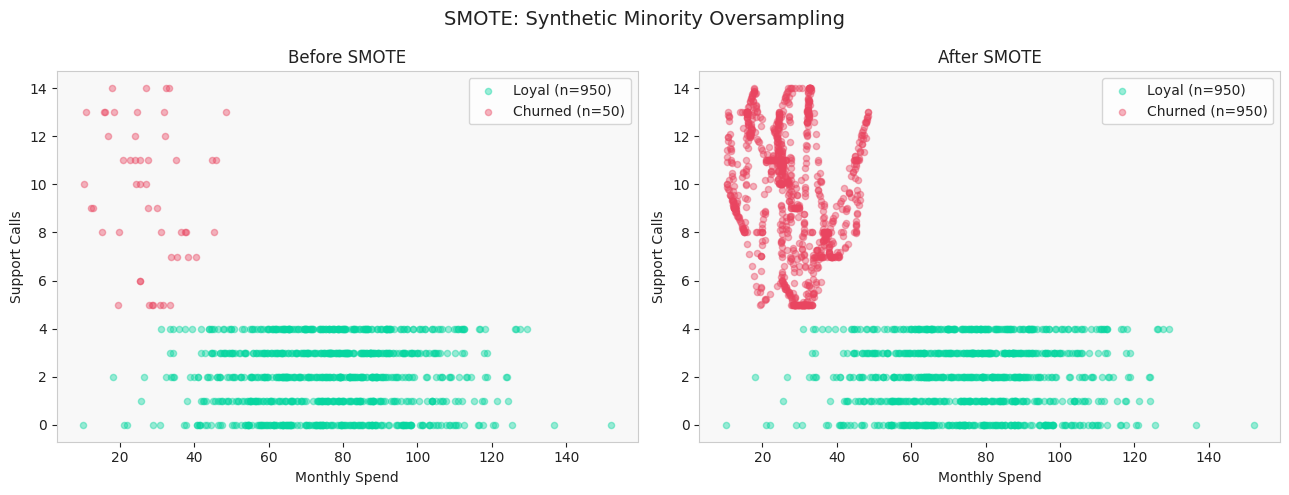

In [59]:
# ── Visualize SMOTE effect ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')
for ax, (X_plot, y_plot, title) in zip(
    axes, [(X, y, 'Before SMOTE'), (X_smote, y_smote, 'After SMOTE')]
):
    ax.set_facecolor('#f8f8f8')
    for label, color, name in [(0, '#06d6a0', 'Loyal'), (1, '#e94560', 'Churned')]:
        mask = y_plot == label
        ax.scatter(
            X_plot[mask, 0],
            X_plot[mask, 2],
            c=color,
            alpha=0.4,
            s=20,
            label=f'{name} (n={mask.sum()})',
        )
    ax.set_title(title, color='#222222', fontsize=12)
    ax.set_xlabel('Monthly Spend', color='#222222')
    ax.set_ylabel('Support Calls', color='#222222')
    ax.legend(facecolor='white', labelcolor='#222222')
plt.suptitle('SMOTE: Synthetic Minority Oversampling', color='#222222', fontsize=14)
plt.tight_layout()
plt.show()

---
<a id="pipelines"></a>
## 8. 🏗️ Building Reusable Cleaning Pipelines

<div style=" border-left:5px solid #e94560; padding:18px; border-radius:8px">

Data cleaning pipelines **automate repetitive tasks**, ensure consistency, and make your code reusable.

**Pipeline output should always be:**
1. ✅ **Clean Data** — ready for analysis/modeling
2. 🚫 **Quarantine File** — rejected records for human review
3. 📋 **Cleaning Log** — what changed, why, how many records affected

</div>


In [61]:
import pandas as pd


class DataCleaningPipeline:
    """
    Flexible, reusable data cleaning pipeline with configurable steps.

    Features:
    - Method chaining (add_step().add_step()...)
    - Automatic execution logging
    - Execution report generation
    """

    def __init__(self, name="Data Cleaning Pipeline"):
        self.name = name
        self.steps = []
        self.execution_log = []

    def add_step(self, name, function, **kwargs):
        """
        Add a cleaning step.

        Parameters
        ----------
        name     : str       — human-readable step name (appears in logs)
        function : callable  — function(df, **kwargs) → df
        **kwargs             — extra arguments passed to the function

        Returns self (enables method chaining)
        """
        self.steps.append({'name': name, 'function': function, 'kwargs': kwargs})
        return self  # ← enables method chaining: .add_step().add_step()

    def execute(self, df, verbose=True):
        """Run all steps in order and return cleaned DataFrame."""
        result = df.copy()  # ← Golden Rule #1
        self.execution_log = []

        for step in self.steps:
            if verbose:
                print(f"  ⚙️  {step['name']}...")
            try:
                # Record before state
                rows_before = len(result)
                nulls_before = result.isna().sum().sum()
                # First .sum() Sums down each column (True=1, False=0)
                # Second .sum() Sums those column totals into a single number

                # Execute step
                result = step['function'](result, **step['kwargs'])

                # Record after state
                rows_after = len(result)
                nulls_after = result.isna().sum().sum()

                # Log execution
                self.execution_log.append(
                    {
                        'step': step['name'],
                        'rows_before': rows_before,
                        'rows_after': rows_after,
                        'rows_changed': rows_after - rows_before,
                        'nulls_before': nulls_before,
                        'nulls_after': nulls_after,
                        'status': 'success',
                    }
                )
            except Exception as e:
                self.execution_log.append(
                    {'step': step['name'], 'status': 'failed', 'error': str(e)}
                )
                if verbose:
                    print(f"     ❌ Error: {e}")
                raise

        if verbose:
            print(f"\n✅ Pipeline '{self.name}' completed successfully!")
        return result

    def get_execution_report(self):
        """Return a DataFrame summarizing each step's effect."""
        return pd.DataFrame(self.execution_log)

    def save_pipeline(self, filename):
        """
        Save pipeline configuration.
        """
        import pickle

        with open(filename, 'wb') as f:
            pickle.dump(self.steps, f)
        print(f"Pipeline saved to {filename}")

    def load_pipeline(self, filename):
        """
        Load pipeline configuration.
        """
        import pickle

        with open(filename, 'rb') as f:
            self.steps = pickle.load(f)
        print(f"Pipeline loaded from {filename}")
        return self


print("✅ DataCleaningPipeline class defined!")

✅ DataCleaningPipeline class defined!


In [60]:
# ── Define modular cleaning functions ────────────────────────────────────


def standardize_column_names(df):
    """Standardize column names. Lowercase + underscore column names."""
    df.columns = (
        df.columns.str.lower()
        .str.replace(' ', '_')
        .str.replace(r'[^a-z0-9_]', '', regex=True)
    )
    return df


def convert_data_types(df, type_mapping=None):
    """
    (Type Coercion) Convert data types based on mapping.
    """
    if type_mapping:
        for col, dtype in type_mapping.items():
            if col in df.columns:
                try:
                    df[col] = df[col].astype(dtype)
                except:
                    print(f"Warning: Could not convert {col} to {dtype}")
    return df


def remove_duplicates(df, subset=None, keep='first'):
    """Drop duplicate rows."""
    return df.drop_duplicates(subset=subset, keep=keep)


def strip_string_cols(df):
    """Strip whitespace from all string columns."""
    cat_cols = df.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        df[col] = df[col].str.strip()
    return df


def handle_missing_numeric(df, strategy='median'):
    """Fill numeric NaNs with mean or median."""
    num_cols = df.select_dtypes(include=['number']).columns
    for col in num_cols:
        fill_val = df[col].mean() if strategy == 'mean' else df[col].median()
        df[col] = df[col].fillna(fill_val)
    return df


def handle_missing_categorical(df, fill_value='Unknown'):
    """Fill string NaNs with a constant."""
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        df[col] = df[col].fillna(fill_value)
    return df


def handle_missing_values(df, strategy='drop', threshold=0.5):
    """Handle missing values."""
    if strategy == 'drop':
        # Drop columns with too many missing values
        missing_pct = df.isna().sum() / len(df)
        cols_to_drop = missing_pct[missing_pct > threshold].index
        df = df.drop(columns=cols_to_drop)
    elif strategy == 'fill_median':
        numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(df[col].median())
    elif strategy == 'fill_mode':
        object_cols = df.select_dtypes(include='object').columns
        for col in object_cols:
            df[col] = df[col].fillna(
                df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
            )
    return df


print("✅ Cleaning functions defined!")

✅ Cleaning functions defined!


<p style="color: steelblue; font-size: 1.5em;">Side Notes</p>

<p style="color: steelblue; font-size: 1.2em;">Note 1:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.8em">

**`cat_cols = df.select_dtypes(include='object').columns`**

**`select_dtypes(include='object')`** filters columns by their data type — `'object'` is how pandas stores **string/text columns**.
```python
df = pd.DataFrame({
    'name':    ['Alice', 'Bob'],    # object  ✓
    'city':    ['Cairo', 'Paris'],  # object  ✓
    'age':     [25, 30],            # int64   ✗
    'salary':  [50.0, 60.0],        # float64 ✗
})

cat_cols = df.select_dtypes(include='object').columns
# Index(['name', 'city'], dtype='object')
```

---

**`.columns`** at the end extracts just the column names as an Index (instead of returning the full DataFrame).

---

**Pandas 3 note — prefer `'string'` over `'object'`:**

In pandas 3, strings have their own dedicated dtype `'string'` (backed by `pd.StringDtype()`), separate from the generic `'object'` dtype. Using `'object'` still works but may catch mixed-type columns unintentionally:
```python
# pandas 3 — more precise
cat_cols = df.select_dtypes(include='string').columns

# or catch both to be safe during transition
cat_cols = df.select_dtypes(include=['object', 'string']).columns
```

---

**Common dtype filters:**
```python
df.select_dtypes(include='string')   # text columns (pandas 3 preferred)
df.select_dtypes(include='object')   # text columns (older style)
df.select_dtypes(include='number')   # all numeric (int + float)
df.select_dtypes(include='float')    # floats only
df.select_dtypes(include='int')      # integers only
df.select_dtypes(exclude='object')   # everything except text
```

---


</div>

In [62]:
# ── Create sample messy dataset ──────────────────────────────────────────
messy_data = {
    'Customer ID': [1, 2, 2, 3, 4, 5, 6],
    'Customer Name': ['  Alice  ', 'BOB', 'BOB', '  Charlie  ', None, 'Eve', '  Frank'],
    'Age': [25, None, 30, 35, 40, None, 28],
    'Purchase Amt': [100, 250.5, 250.5, None, 400, 550, 75],
    'Category': [
        'Electronics',
        None,
        'Electronics',
        'Clothing',
        'Books',
        None,
        'Clothing',
    ],
}
df_messy = pd.DataFrame(messy_data)

print("📊 Messy Data:")
print(df_messy)
print(f"\nShape: {df_messy.shape}   |   Missing values: {df_messy.isna().sum().sum()}")

📊 Messy Data:
   Customer ID Customer Name   Age  Purchase Amt     Category
0            1       Alice    25.0         100.0  Electronics
1            2           BOB   NaN         250.5          NaN
2            2           BOB  30.0         250.5  Electronics
3            3     Charlie    35.0           NaN     Clothing
4            4           NaN  40.0         400.0        Books
5            5           Eve   NaN         550.0          NaN
6            6         Frank  28.0          75.0     Clothing

Shape: (7, 5)   |   Missing values: 6


In [ ]:
# ── Build and execute the pipeline ───────────────────────────────────────
pipeline = DataCleaningPipeline("Customer Data Cleaning")

(
    pipeline.add_step("Standardize Column Names", standardize_column_names)
    .add_step("Strip String Whitespace", strip_string_cols)
    .add_step("Remove Duplicates", remove_duplicates, subset=['customer_id'])
    .add_step("Handle Missing Numeric", handle_missing_numeric, strategy='median')
    .add_step(
        "Handle Missing Categorical", handle_missing_categorical, fill_value='Unknown'
    )
)
# NOTE: The outer () is just a Python trick to allow line continuation without needing backslashes.

print(f"Pipeline '{pipeline.name}' — Steps defined: {len(pipeline.steps)}\n")
print("─" * 80)
df_cleaned = pipeline.execute(df_messy)

print("\nUNcleaned Data:")
print(df_messy)
print("\n📊 Cleaned Data:")
print(df_cleaned)
print(
    f"\nShape: {df_cleaned.shape}   |   Missing values: {df_cleaned.isna().sum().sum()}"
)

Pipeline 'Customer Data Cleaning' — Steps defined: 5

────────────────────────────────────────────────────────────────────────────────
  ⚙️  Standardize Column Names...
  ⚙️  Strip String Whitespace...
  ⚙️  Remove Duplicates...
  ⚙️  Handle Missing Numeric...
  ⚙️  Handle Missing Categorical...

✅ Pipeline 'Customer Data Cleaning' completed successfully!

UNcleaned Data:
   Customer ID Customer Name   Age  Purchase Amt     Category
0            1       Alice    25.0         100.0  Electronics
1            2           BOB   NaN         250.5          NaN
2            2           BOB  30.0         250.5  Electronics
3            3     Charlie    35.0           NaN     Clothing
4            4           NaN  40.0         400.0        Books
5            5           Eve   NaN         550.0          NaN
6            6         Frank  28.0          75.0     Clothing

📊 Cleaned Data:
   customer_id customer_name   age  purchase_amt     category
0            1         Alice  25.0         100.0  

<p style="color: steelblue; font-size: 1.5em;">Side Notes</p>

<p style="color: steelblue; font-size: 1.2em;">Note 1:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.8em">

**Why the outer `()` in the pipeline.add_step() chain?**

The outer `()` is just a **Python trick to allow line continuation** without needing backslashes.
```python
# Without () — needs ugly backslashes to span multiple lines
pipeline \
    .add_step("Standardize Column Names", standardize_column_names) \
    .add_step("Strip String Whitespace", strip_string_cols)

# With () — clean, no backslashes needed
(
    pipeline
    .add_step("Standardize Column Names", standardize_column_names)
    .add_step("Strip String Whitespace", strip_string_cols)
)
```

Python allows any expression inside `()` to span multiple lines freely. Since `pipeline.add_step().add_step()...` is one long chained expression, wrapping it in `()` lets you break it across lines cleanly.

The `()` don't do anything functionally — they're purely for **formatting**.
</div>

In [69]:
# ── Execution Report ─────────────────────────────────────────────────────
report = pipeline.get_execution_report()
print("📋 Execution Report:")
print(
    report[
        [
            'step',
            'rows_before',
            'rows_after',
            'rows_changed',
            'nulls_before',
            'nulls_after',
            'status',
        ]
    ].to_string(index=False)
)

📋 Execution Report:
                      step  rows_before  rows_after  rows_changed  nulls_before  nulls_after  status
  Standardize Column Names            7           7             0             6            6 success
   Strip String Whitespace            7           7             0             6            6 success
         Remove Duplicates            7           6            -1             6            6 success
    Handle Missing Numeric            6           6             0             6            3 success
Handle Missing Categorical            6           6             0             3            0 success


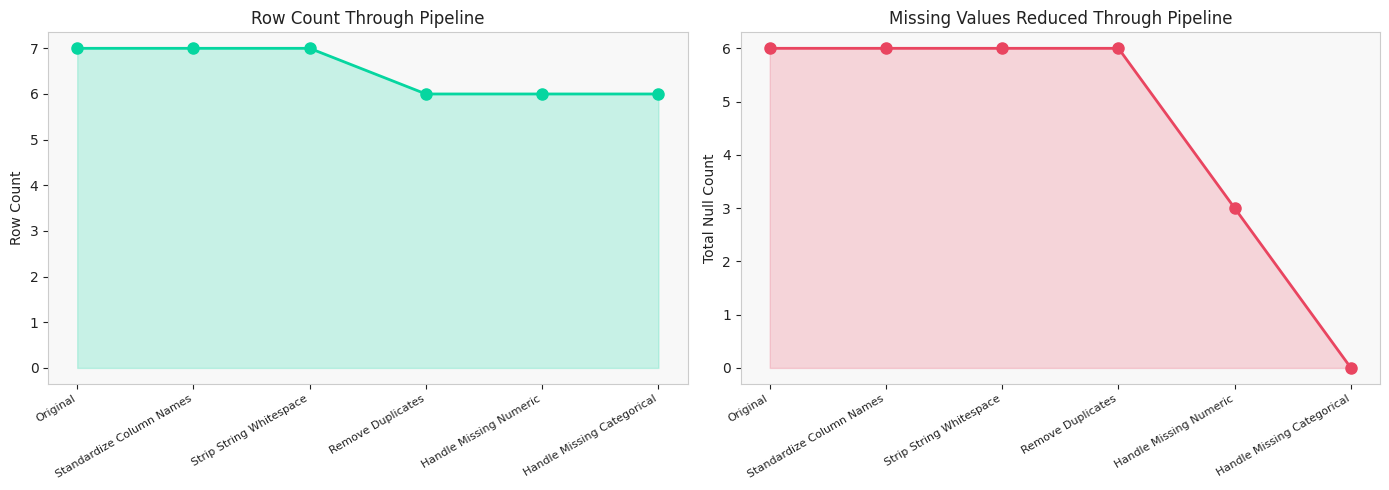

In [70]:
# Visualize the pipeline flow
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# Row count progression
ax1.set_facecolor('#f8f8f8')
steps = ['Original'] + report['step'].tolist()
rows = [report['rows_before'].iloc[0]] + report['rows_after'].tolist()
ax1.plot(range(len(steps)), rows, 'o-', color='#06d6a0', linewidth=2, markersize=8)
ax1.set_xticks(range(len(steps)))
ax1.set_xticklabels(steps, rotation=30, ha='right', fontsize=8, color='#222222')
ax1.set_ylabel('Row Count', color='#222222')
ax1.set_title('Row Count Through Pipeline', color='#222222', fontsize=12)
ax1.fill_between(range(len(steps)), rows, alpha=0.2, color='#06d6a0')

# Null count progression
ax2.set_facecolor('#f8f8f8')
nulls = [report['nulls_before'].iloc[0]] + report['nulls_after'].tolist()
ax2.plot(range(len(steps)), nulls, 'o-', color='#e94560', linewidth=2, markersize=8)
ax2.set_xticks(range(len(steps)))
ax2.set_xticklabels(steps, rotation=30, ha='right', fontsize=8, color='#222222')
ax2.set_ylabel('Total Null Count', color='#222222')
ax2.set_title('Missing Values Reduced Through Pipeline', color='#222222', fontsize=12)
ax2.fill_between(range(len(steps)), nulls, alpha=0.2, color='#e94560')

plt.tight_layout()
plt.show()

---
## 📖 Summary: Complete Data Cleaning Cheat Sheet

<div style="background: linear-gradient(135deg, #1a1a2e, #16213e); border: 1px solid #0f9b8e; border-radius: 12px; padding: 25px; color: #b0b8c8;">

<style>
div .highlight-table code { color: #7dd3c8 !important; background: transparent !important; }
</style>

<div class="highlight-table">

| Issue | Detection | Strategy | Key Functions |
|-------|-----------|----------|---------------|
| **Accuracy** | Domain rules | Rule-based fix or reject | `apply()`, `loc[]`, boolean masks |
| **Consistency** | `value_counts()` | Standardize + type coerce | `str.lower()`, `.map()`, `pd.to_numeric()` |
| **Missing (MCAR<5%)** | `isnull().sum()` | Delete rows | `dropna()` |
| **Missing (numeric)** | `isnull()` heatmap | Mean / Median imputation | `SimpleImputer`, `fillna()` |
| **Missing (categorical)** | `isnull()` | Mode or 'Unknown' | `fillna('Unknown')` |
| **Missing (advanced)** | Correlation check | KNN / MICE |